In [2]:
import pandas as pd
import numpy as np
from pandas.tseries.frequencies import to_offset

from merlion.models.anomaly.autoencoder import AutoEncoder, AutoEncoderConfig
from merlion.transform.normalize import MeanVarNormalize
from merlion.post_process.threshold import AggregateAlarms
from merlion.evaluate.anomaly import TSADMetric
from merlion.utils import TimeSeries
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    f1_score,
    average_precision_score,
    precision_recall_fscore_support,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    auc
)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import time
import json
import random
import torch
import os

def set_seed(seed=42):
    #os.environ['PYTHONHASHSEED'] = str(seed)
    #os.environ["OMP_NUM_THREADS"] = "1"
    #os.environ["MKL_NUM_THREADS"] = "1"
    #os.environ["OPENBLAS_NUM_THREADS"] = "1"
    #os.environ["NUMEXPR_NUM_THREADS"] = "1"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    #torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
def find_gaps_longer_than(
    df,
    datetime_col=None,
    freq='1min',
    threshold_min=5,
    columns_to_check=None,
    keep_datetime_index=True
):
    '''
    Находит интервалы пропусков длиннее заданного порога
    в столбцах временного ряда.

    Параметры:
        df (pd.DataFrame): исходный DataFrame
        datetime_col (str | None): столбец с датой/временем, если индекс не DatetimeIndex
        freq (str): частота приведения ряда
        threshold_min (int): минимальная длина пропуска в минутах
        columns_to_check (list | None): столбцы для проверки
        keep_datetime_index (bool): сохранять ли DatetimeIndex после asfreq

    Возвращает:
        pd.DataFrame: таблица интервалов пропусков с колонками
        ['column', 'start', 'end', 'length_min']
    '''
    df = df.copy()

    # --- Подготовка временного индекса ---
    if datetime_col is not None and datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col])
        df = df.set_index(datetime_col).sort_index()
    elif not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError('Индекс не DatetimeIndex и не указан столбец с датой/временем.')
    else:
        df = df.sort_index()

    # Округление до минут
    df.index = df.index.floor('min')

    # --- Агрегация дубликатов ---
    df = df.groupby(df.index).mean()

    # Приведение к равномерной частоте
    df = df.asfreq(freq)

    # Опционально: сброс индекса (если нужно, но тогда временные метки будут потеряны)
    if not keep_datetime_index:
        df = df.reset_index()

    # --- Определение столбцов для проверки ---
    if columns_to_check is None:
        columns_to_check = df.columns.tolist()
    # Убедимся, что все столбцы существуют
    columns_to_check = [c for c in columns_to_check if c in df.columns]

    if not columns_to_check:
        return pd.DataFrame(columns=['column', 'start', 'end', 'length_min'])

    # --- Поиск пропусков ---
    gaps_records = []

    for col in columns_to_check:
        is_nan = df[col].isna() | df.isna().all(axis=1)
        # Группируем последовательные NaN
        groups = (is_nan != is_nan.shift()).cumsum()
        nan_groups = df[is_nan].groupby(groups[is_nan])

        for _, group in nan_groups:
            length = len(group)
            if length > threshold_min:
                start = group.index[0] if keep_datetime_index else group.iloc[0]['index']
                end = group.index[-1] if keep_datetime_index else group.iloc[-1]['index']
                gaps_records.append({
                    'column': col,
                    'start': start,
                    'end': end,
                    'length_min': length
                })

    gaps_df = pd.DataFrame(gaps_records)
    return gaps_df

In [4]:
def event_lengths(events):
    '''
    Вычисляет минимальную и медианную длительность событий в минутах.

    Параметры:
        events (list[list[str, str]]): список интервалов [[start, end], ...]

    Возвращает:
        dict: {
            'min': минимальная длительность,
            'median': медианная длительность
        }
    '''
    durations = []
    for start, end in events:
        start = pd.to_datetime(start)
        end = pd.to_datetime(end)

        duration = (end - start).total_seconds() / 60
        durations.append(duration)

    return {
        'min': min(durations),
        'median': np.median(durations)
    }

def event_params(min_event_len, median_event_len):
    '''
    Рассчитывает стартовые параметры для пайплайна на основе длительности событий.

    Параметры:
        min_event_len (float): минимальная длительность события (мин)
        median_event_len (float): медианная длительность события (мин)

    Возвращает:
        tuple[int, int, int, int]:
            (gap_fill, min_event, event_interval, window_size)
            — параметры, ограниченные заданными диапазонами
    '''

    def clip(value, vmin, vmax):
        return max(vmin, min(value, vmax))

    gap_fill = clip(min_event_len, 3, 15)
    min_event = clip(min_event_len * 0.5, 3, 120)
    event_interval = clip(median_event_len * 4 / 5, 20, 300)
    window_size = clip(median_event_len * 0.4, 5, 120)

    return int(gap_fill), int(min_event), int(event_interval), int(window_size)

def pr_auc(y_true, scores):
    '''
    PR-AUC / Average Precision
    '''
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    return average_precision_score(y_true, scores)

def binary_to_events(y_bin: pd.Series, gap_minutes=10, min_len_minutes=5):
    '''
    Преобразует бинарный временной ряд (0/1) в список событий (start, end).

    Объединяет точки со значением 1 в события, если разрыв между ними
    не превышает gap_minutes, и отбрасывает события короче min_len_minutes.

    Параметры:
        y_bin (pd.Series): временной ряд с индексом datetime и значениями 0/1
        gap_minutes (int): максимальный разрыв (в минутах) для объединения
        min_len_minutes (int): минимальная длительность события (в минутах)

    Возвращает:
        List[Tuple[pd.Timestamp, pd.Timestamp]]: список интервалов (start, end)
    '''
    y_bin = y_bin.sort_index().astype(int)
    ones = y_bin[y_bin == 1].dropna()
    if ones.empty:
        return []

    gap = pd.Timedelta(minutes=gap_minutes)
    min_len = pd.Timedelta(minutes=min_len_minutes)

    times = ones.index
    events = []
    start = prev = times[0]

    for t in times[1:]:
        if (t - prev) <= gap:
            prev = t
        else:
            end = prev
            if (end - start) >= min_len:
                events.append((start, end))
            start = prev = t

    end = prev
    if (end - start) >= min_len:
        events.append((start, end))

    return events

def f1_at_fpr(y_true, scores, target_fpr=0.01):
    '''
    Вычисляет F1-меру при ограничении на уровень ложноположительных срабатываний(FPR).

    Параметры:
        y_true (array-like): бинарные метки (0 — норма, 1 — аномалия)
        scores (array-like): anomaly score
        target_fpr (float): максимальный допустимый FPR

    Возвращает:
        float: значение F1 при пороге, дающем FPR ≤ target_fpr
    '''
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    fpr, tpr, thresholds = roc_curve(y_true, scores)

    valid_idx = np.where(fpr <= target_fpr)[0]
    if len(valid_idx) == 0:
        return 0.0

    idx = valid_idx[-1]
    threshold = thresholds[idx]

    y_pred = (scores >= threshold).astype(int)
    return f1_score(y_true, y_pred, zero_division=0)

def precision_at_k(y_true, scores, k):
    '''
    Вычисляет Precision@K — долю аномалий среди K наибольших score.

    Параметры:
        y_true (array-like): бинарные метки (0/1)
        scores (array-like): оценки аномальности (чем больше, тем выше ранг)
        k (int): количество топ-элементов

    Возвращает:
        float: Precision@K
    '''
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    if k <= 0:
        raise ValueError('k must be > 0')

    if len(y_true) == 0:
        return 0.0

    k = min(k, len(y_true))
    top_k_idx = np.argsort(scores)[::-1][:k]

    return float(y_true[top_k_idx].sum() / k)

def recall_at_k(y_true, scores, k):
    '''
    Вычисляет Recall@K — долю всех аномалий, попавших в топ-K по score.

    Параметры:
        y_true (array-like): бинарные метки (0/1)
        scores (array-like): оценки аномальности
        k (int): количество топ-элементов

    Возвращает:
        float: Recall@K
    '''
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    if k <= 0:
        raise ValueError('k must be > 0')

    total_anomalies = y_true.sum()
    if total_anomalies == 0:
        return 0.0

    k = min(k, len(y_true))
    top_k_idx = np.argsort(scores)[::-1][:k]
    found_anomalies = y_true[top_k_idx].sum()

    return float(found_anomalies / total_anomalies)

def _overlap(start1, end1, start2, end2):
    '''
    Проверяет, пересекаются ли два временных интервала.

    Параметры:
        start1, end1: границы первого интервала
        start2, end2: границы второго интервала

    Возвращает:
        bool: True, если интервалы пересекаются, иначе False
    '''
    return not (end1 < start2 or end2 < start1)

def _inside_true_event(pred_start, pred_end, true_start, true_end):
    '''
    Проверяет, находится ли предсказанное событие полностью внутри истинного.

    Параметры:
        pred_start, pred_end: границы предсказанного интервала
        true_start, true_end: границы истинного интервала

    Возвращает:
        bool: True, если предсказанное событие полностью внутри истинного
    '''
    return true_start <= pred_start and pred_end <= true_end

def _is_timely_detection(pred_start, true_start, max_min=180):
    '''
    Проверяет, является ли предсказание своевременным относительно истинного события.

    Параметры:
        pred_start: время начала предсказанного события
        true_start: время начала истинного события
        max_min (int): допустимое отклонение (в минутах)

    Возвращает:
        bool: True, если pred_start находится в окне вокруг true_start
    '''
    window = pd.Timedelta(minutes=max_min)
    return (true_start - window) <= pred_start <= (true_start + window)

def event_recall(true_events, pred_events, max_min=180):
    '''
    Вычисляет Event Recall — долю найденных истинных событий.

    Событие считается найденным, если существует предсказанное событие,
    которое пересекается с ним и начинается в допустимом временном окне.

    Параметры:
        true_events (list[tuple]): истинные интервалы (start, end)
        pred_events (list[tuple]): предсказанные интервалы (start, end)
        max_min (int | float): допустимое отклонение по времени (мин)

    Возвращает:
        float: Event Recall
    '''
    if len(true_events) == 0:
        return 0.0

    detected = 0

    for t_start, t_end in true_events:
        found = False

        for p_start, p_end in pred_events:
            if _overlap(t_start, t_end, p_start, p_end) and _is_timely_detection(
                p_start, t_start, max_min=max_min
            ):
                found = True
                break

        if found:
            detected += 1

    return detected / len(true_events)

def event_precision(true_events, pred_events, max_min=180):
    '''
    Вычисляет Event Precision — долю корректных предсказанных событий.

    Предсказание считается корректным, если:
    1) оно своевременно обнаруживает истинное событие, или
    2) находится внутри истинного события.

    Параметры:
        true_events (list[tuple]): истинные интервалы (start, end)
        pred_events (list[tuple]): предсказанные интервалы (start, end)
        max_min (int | float): допустимое отклонение по времени (мин)

    Возвращает:
        float: Event Precision
    '''
    if len(pred_events) == 0:
        return 0.0

    correct_pred_idx = set()

    for t_start, t_end in true_events:
        for i, (p_start, p_end) in enumerate(pred_events):
            if _overlap(t_start, t_end, p_start, p_end) and _is_timely_detection(
                p_start, t_start, max_min=max_min
            ):
                timely_exists = True
                correct_pred_idx.add(i)

            if _inside_true_event(p_start, p_end, t_start, t_end):
                correct_pred_idx.add(i)

    return len(correct_pred_idx) / len(pred_events)

def time_to_detect(true_events, pred_events, reduction='mean', unit='minutes', max_min=180):
    '''
    Вычисляет Time-to-Detect — задержку обнаружения событий.

    Для каждого истинного события берётся самое раннее предсказание,
    которое пересекается с ним и попадает в допустимое временное окно.

    Параметры:
        true_events (list[tuple]): истинные интервалы (start, end)
        pred_events (list[tuple]): предсказанные интервалы (start, end)
        reduction (str): 'mean', 'median' или 'list'
        unit (str): единицы измерения ('seconds', 'minutes', 'hours')
        max_min (int | float): допустимое отклонение по времени (мин)

    Возвращает:
        float | list | np.nan: агрегированная или список задержек
    '''
    window = pd.Timedelta(minutes=max_min)
    delays = []

    for t_start, t_end in true_events:
        valid_starts = []

        for p_start, p_end in pred_events:
            if _overlap(t_start, t_end, p_start, p_end) and (
                (t_start - window) <= p_start <= (t_start + window)
            ):
                valid_starts.append(p_start)

        if valid_starts:
            first_detection = min(valid_starts)
            delay = first_detection - t_start
            delays.append(_convert_unit(delay, unit))

    if not delays:
        return np.nan

    if reduction == 'list':
        return delays
    if reduction == 'mean':
        return float(np.mean([abs(i) for i in delays]))
    if reduction == 'median':
        return float(np.median([abs(i) for i in delays]))

    raise ValueError('reduction must be mean, median, or list')

def _convert_unit(td, unit):
    '''
    Конвертирует timedelta в заданные единицы времени.

    Параметры:
        td (pd.Timedelta): временной интервал
        unit (str): единицы ('seconds', 'minutes', 'hours')

    Возвращает:
        float: значение в выбранных единицах
    '''
    seconds = td.total_seconds()

    if unit == 'seconds':
        return seconds
    if unit == 'minutes':
        return seconds / 60.0
    if unit == 'hours':
        return seconds / 3600.0

    raise ValueError('unit must be seconds, minutes, or hours')

def alerts_per_day(pred_events, timestamps):
    '''
    Вычисляет среднее количество алертов (событий) в день.

    Параметры:
        pred_events (list[tuple]): предсказанные интервалы (start, end)
        timestamps (pd.DatetimeIndex): временной диапазон наблюдений

    Возвращает:
        float: количество событий в день
    '''
    duration_days = (timestamps.max() - timestamps.min()).total_seconds() / 86400

    if duration_days == 0:
        return 0

    return len(pred_events) / duration_days

def add_results(
    df,
    model_name,
    pr_auc,
    f1_at_fpr_1,
    recall,
    precision,
    precision_at_100,
    recall_at_100,
    event_recall,
    event_precision,
    f1_event,
    ttd_mean,
    ttd_median,
    alerts,
    n_true_events,
    n_pred_events,
    train_time_sec,
    inference_time_sec,
    model_params,
    threshold,
    f1_anom
):
    '''
    Добавляет результаты модели в DataFrame.
    '''
    safe_model_params = make_json_serializable(model_params)
    row = {
        'PR-AUC': round(pr_auc*100, 2),
        'F1@FPR5%': round(f1_at_fpr_1*100, 2),
        'Recall': round(recall*100, 2),
        'Precision': round(precision*100, 2),
        'Precision@100': round(precision_at_100*100, 2),
        'Recall@100': round(recall_at_100*100, 2),
        'Event Recall': round(event_recall*100, 2),
        'Event Precision': round(event_precision*100, 2),
        'F1 event': round(f1_event*100, 2),
        'TTD mean': round(ttd_mean, 2),
        'TTD median': round(ttd_median, 2),
        'Alerts per day': round(alerts, 2),
        'n true events': n_true_events,
        'n pred events': n_pred_events,
        'threshold': threshold,
        'train time sec': round(train_time_sec, 2) if train_time_sec is not None else pd.NA,
        'inference time sec': round(inference_time_sec, 2) if inference_time_sec is not None else pd.NA,
        'model params': json.dumps(safe_model_params, ensure_ascii=False),
        'F1_anom': round(f1_anom*100, 2)
    }
    if df.empty:
        df = pd.DataFrame(columns=row.keys())

    for col in row.keys():
        if col not in df.columns:
            df[col] = pd.NA

    df.loc[f'{model_name}'] = row
    return df

def change_pr(
    df,
    model_name,
    recall,
    precision,
    f1_anom
):
    df.loc[model_name, 'Recall'] = round(recall*100, 2)
    df.loc[model_name, 'Precision'] = round(precision*100, 2)
    df.loc[model_name, 'F1_anom'] = round(f1_anom*100, 2)
    return df

def make_json_serializable(obj):
    '''
    Приводит объект к JSON-сериализуемому виду.

    Поддерживает базовые типы, numpy, списки, словари,
    pandas Timestamp/Timedelta и рекурсивно обрабатывает вложенные структуры.

    Параметры:
        obj: произвольный объект

    Возвращает:
        JSON-совместимое представление объекта
    '''
    if obj is None:
        return None
    if isinstance(obj, (str, int, float, bool)):
        return obj
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (list, tuple)):
        return [make_json_serializable(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()
    if isinstance(obj, pd.Timedelta):
        return str(obj)

    # для объектов вроде Identity, sklearn/torch transforms и т.п.
    return str(obj)

def plot_pr_curve(y_true, y_scores, model_name='model'):
    '''
    Строит Precision-Recall кривую и возвращает PR-AUC.

    Параметры:
        y_true (array-like): бинарные метки (0/1)
        y_scores (array-like): anomaly score
        model_name (str): имя модели для легенды

    Возвращает:
        float: значение PR-AUC
    '''
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=recall,
        y=precision,
        mode='lines',
        name=f'{model_name} (PR-AUC={pr_auc:.4f})'
    ))

    fig.update_layout(
        title='Precision-Recall Curve',
        xaxis_title='Recall',
        yaxis_title='Precision',
        template='plotly_white'
    )

    fig.show()

    return pr_auc

def rank_transform(scores, ascending=True):
    scores = pd.Series(scores)
    return scores.rank(method='average', pct=True, ascending=ascending)

def calibrate_scores_by_val(val_scores_series, test_scores_series, higher_is_more_anomalous=True):
    val_scores_series = pd.Series(val_scores_series).dropna().sort_values().reset_index(drop=True)
    test_scores_series = pd.Series(test_scores_series)

    val_array = val_scores_series.to_numpy()
    test_array = test_scores_series.to_numpy()
    print(len(val_array))
    if higher_is_more_anomalous:
        # доля val-значений <= test_score
        calibrated = np.searchsorted(val_array, test_array, side="right") / len(val_array)
    else:
        # доля val-значений >= test_score
        calibrated = 1.0 - (np.searchsorted(val_array, test_array, side="left") / len(val_array))

    return pd.Series(calibrated, index=test_scores_series.index)

def add_target_column(
    df,
    anomaly_intervals,
    target_col_name='target',
    inclusive='both'
):
    '''
    Добавляет в DataFrame бинарный столбец target по интервалам аномалий.

    Параметры:
        df (pd.DataFrame): датафрейм с DatetimeIndex
        anomaly_intervals (list | pd.DataFrame): интервалы аномалий
        target_col_name (str): имя нового столбца
        inclusive (str): режим включения границ интервала

    Возвращает:
        pd.DataFrame: копия исходного DataFrame со столбцом target
    '''
    df = df.copy()  # чтобы не менять оригинал
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError('Индекс DataFrame должен быть DatetimeIndex.')

    # Приводим anomaly_intervals к единому формату списка кортежей (start, end)
    if isinstance(anomaly_intervals, pd.DataFrame):
        if not {'start', 'end'}.issubset(anomaly_intervals.columns):
            raise ValueError("DataFrame с интервалами должен содержать колонки 'start' и 'end'.")
        intervals = list(zip(anomaly_intervals['start'], anomaly_intervals['end']))
    elif isinstance(anomaly_intervals, list):
        intervals = anomaly_intervals
    else:
        raise TypeError('anomaly_intervals должен быть списком кортежей или DataFrame.')

    # Преобразуем границы в pandas Timestamp для надёжности
    intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in intervals]

    # Если интервалов нет, весь target = 0
    if not intervals:
        df[target_col_name] = 0
        return df

    # Создаём IntervalIndex из интервалов (для быстрой проверки принадлежности)
    # Учитываем параметр inclusive
    closed_map = {
        'both': 'both',
        'left': 'left',
        'right': 'right',
        'neither': 'neither'
    }
    if inclusive not in closed_map:
        raise ValueError("inclusive должен быть одним из: 'both', 'left', 'right', 'neither'")
    closed = closed_map[inclusive]

    interval_index = pd.IntervalIndex.from_tuples(intervals, closed=closed)

    # Создаём маску: для каждой временной метки проверяем, попадает ли она в любой интервал
    # Используем list comprehension с any, но для больших данных эффективнее использовать
    # векторизованный подход: создать массив с помощью IntervalIndex.get_indexer
    # Однако get_indexer возвращает -1, если не входит, иначе индекс интервала.
    # Это быстрее для одного массива.
    indices = interval_index.get_indexer(df.index)
    mask = indices != -1  # True, если метка принадлежит какому-либо интервалу

    df[target_col_name] = mask.astype(int)

    return df

def add_target_column1(df):
    data = df.copy()
    # 1. Метка «авария сейчас» (включая равенство порогу)
    data['is_failure'] = 0
    data.loc[(data.iloc[:, 0] >= -7) | (data.iloc[:, 1] >= 80), 'is_failure'] = 1

    # 2. Идентификация непрерывных блоков аварий
    #data['_block'] = (data['is_failure'].diff() == 1).cumsum()
    #data.loc[data['is_failure'] == 0, '_block'] = 0

    # 3. Целевая переменная (по умолчанию 0)
    data['target'] = 0

    # 3. Получаем все позиции, где is_failure == 1
    failure_positions = data[data['is_failure'] == 1].index
    if len(failure_positions) == 0:
        return data

    # 4. Для каждой позиции аварии
    for pos in failure_positions:
        pos_idx = data.index.get_loc(pos)                # позиционный индекс (int)
        left = max(0, pos_idx - 10)
        # Ставим target = 1 на [left, pos_idx] включительно
        data.iloc[left:pos_idx + 1, data.columns.get_loc('target')] = 1

    # 5. Убираем единицы в самих моментах аварии
    data.loc[data['is_failure'] == 1, 'target'] = 0
            
            # 4. Для каждого блока – окно предупреждения [начало - horizon, начало)
            #for block_id in data[data['is_failure'] == 1]['_block'].unique():
            #    if block_id == 0:
            #        continue
            #    block_mask = data['_block'] == block_id
            #    start_idx = data[block_mask].index[0]
            #    start_pos = data.index.get_loc(start_idx)
            #    left_pos = max(0, start_pos - self.outer.forecast_horizon)
            #    data.iloc[left_pos:start_pos, data.columns.get_loc('target')] = 1

            #data.drop(columns=['_block'], inplace=True)
    return data

def get_failure_lengths(data):
    df = data.copy()

    # блоки аварий
    df['_block'] = (df['is_failure'].diff() == 1).cumsum()
    df.loc[df['is_failure'] == 0, '_block'] = np.nan

    # считаем длины блоков
    block_lengths = df.groupby('_block').size().dropna()

    return {
        "min_length": int(block_lengths.min()) if not pd.isna(block_lengths.min()) else 0,
        "median_length": float(block_lengths.median()) if not pd.isna(block_lengths.median()) else 0
    }

def get_anomaly_lengths_time(data):
    target = data['target']
    target.index = pd.to_datetime(target.index)

    lengths = []
    current_start = None

    for t, val in target.items():
        if val == 1:
            if current_start is None:
                current_start = t
        else:
            if current_start is not None:
                duration = (t - current_start).total_seconds() / 60
                lengths.append(duration)
                current_start = None

    # если аномалия до конца
    if current_start is not None:
        duration = (target.index[-1] - current_start).total_seconds() / 60
        lengths.append(duration)

    if not lengths:
        return 0, 0

    return float(min(lengths)), float(np.median(lengths))

def preprocess_with_adtk(
    df,
    columns=None,
    mode="flag",
    window=5,
    c=3.0,
    side="both",
    min_non_nan=3,
):
    df = df.copy()

    if columns is None:
        columns = [col for col in df.columns if col != "target"]

    dt_index = pd.to_datetime(df.index)

    for col in columns:
        series = pd.Series(df[col].values, index=dt_index, name=col)

        # PersistAD не имеет смысла для нечисловых колонок
        if not pd.api.types.is_numeric_dtype(series):
            continue

        non_nan_count = series.notna().sum()
        if non_nan_count < min_non_nan:
            if mode == "flag":
                df[f"{col}_adtk_persist"] = 0
            continue

        try:
            validated = validate_series(series)
            detector = PersistAD(window=window, c=c, side=side)
            outliers = detector.fit_detect(validated)
            outliers = outliers.fillna(False).astype(int)
        except Exception:
            # если ADTK не смог обработать колонку — просто пропускаем ее
            if mode == "flag":
                df[f"{col}_adtk_persist"] = 0
            continue

        mask = outliers.astype(bool).values

        if mode == "flag":
            df[f"{col}_adtk_persist"] = outliers.values

        elif mode == "nan":
            df.loc[mask, col] = np.nan

        elif mode == "median":
            median_val = df[col].median()
            df.loc[mask, col] = median_val

        else:
            raise ValueError("mode must be 'flag', 'nan', or 'median'")

    return df

In [5]:
def train_func(num_data,
               config,
               list_anomaly,
               model_name_result,
               q,
               alpha=1,
               train_time_sec=None,
               inference_time_sec=None,
               val_score=None,
               test_score_outside=None,
               save_result = False,
               no_train = True,
               use_miss=True):
    """
    Включает:
    - загрузку и нормализацию train/val/test данных
    - вычисление параметров событий (включая window_size)
    - обучение модели (если no_train=False)
    - получение anomaly score для val/test
    - бинаризацию по порогу (quantile q * alpha)
    - расчёт point-level и event-level метрик
    - визуализацию и (опционально) сохранение результатов

    Параметры:
    ----------
    num_data : int
        Номер датасета (используется для загрузки файлов).
    model : callable
        Класс модели (например, DAGMM).
    list_anomaly : list
        Список интервалов аномалий для расчёта event-параметров.
    config : object
        Конфигурация модели (будет дополнена window_size).
    model_name_result : str
        Имя модели для сохранения результатов.
    q : float
        Квантиль для порога.
    alpha : float
        Множитель порога.
    val_score : pd.Series, optional
        Внешние val scores (если no_train=True).
    test_score_outside : pd.Series или list, optional
        Внешние test scores (если no_train=True).
    save_result : bool
        Сохранять ли метрики в Excel.
    no_train : bool
        Если True — модель не обучается, используются внешние score.
    use_miss : bool
        Использовать ли признаки с miss_.

    Возвращает:
    -----------
    model : object
        Обученная модель (или None).
    val_score : pd.Series
        Аномальные оценки для validation.
    test_score : pd.Series
        Аномальные оценки для test.
    """
    
    # загрузка
    train = pd.read_csv(f'data_post/{num_data}/train{num_data}.csv', index_col=0)
    val = pd.read_csv(f'data_post/{num_data}/val{num_data}.csv', index_col=0)

    if not use_miss:
        target_cols = [c for c in train.columns if c == c.replace('miss_', '', 1)]
        train, val = train[target_cols], val[target_cols]
        target_cols.append('target')
    print(f'Размерности: train: {train.shape}, val: {val.shape}')
    # список блоков аномалий
    min_len, median_len = event_lengths(list_anomaly)['min'], event_lengths(list_anomaly)['median']
    gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
    model_train.config.sequence_len = window_size
    print(f'Параметры исследования аномалий: максимальный пропуск: {gap_fill}, минимальная длина аномалии: {min_event}, \
интервал вокруг начала аномалии: {event_interval}, размер окна: {window_size}')
    # Выделяем признаки (исключаем целевую переменную)
    feature_names = [col for col in train.columns]
    # стандартизация
    scaler = RobustScaler()
    train_scaled = scaler.fit_transform(train[feature_names])
    val_scaled = scaler.transform(val[feature_names])
    # в датафрейм
    train_norm = pd.DataFrame(train_scaled, index=train.index, columns=feature_names)
    val_norm = pd.DataFrame(val_scaled, index=val.index, columns=feature_names)
    # преобразование в TimeSeries
    train_data = TimeSeries.from_pd(train_norm)
    val_data = TimeSeries.from_pd(val_norm)

    # тестовые данные
    if num_data == 6:
        test1 = pd.read_csv(f'data_post/{num_data}/test{num_data}1.csv', index_col=0)
        test2 = pd.read_csv(f'data_post/{num_data}/test{num_data}2.csv', index_col=0)

        if not use_miss:
            test1 = test1[target_cols]
            test2 = test2[target_cols]
        test_scaled1 = scaler.transform(test1[feature_names])
        test_scaled2 = scaler.transform(test2[feature_names])
        test_norm1 = pd.DataFrame(test_scaled1, index=test1.index, columns=feature_names)
        test_norm2 = pd.DataFrame(test_scaled2, index=test2.index, columns=feature_names)
        test_data1 = TimeSeries.from_pd(test_norm1)
        test_data2 = TimeSeries.from_pd(test_norm2)
        test_data = pd.concat([test1, test2]).sort_index()
        y_true = pd.concat([test1['target'], test2['target']])
        y_true.index = pd.to_datetime(y_true.index)
        y_true = y_true.sort_index()

    else:
        test = pd.read_csv(f'data_post/{num_data}/test{num_data}.csv', index_col=0)
        if not use_miss:
            test = test[target_cols]
        test_scaled = scaler.transform(test[feature_names])
        test_norm = pd.DataFrame(test_scaled, index=test.index, columns=feature_names)
        test_data = TimeSeries.from_pd(test_norm)
        y_true = test['target'].astype(int)
        y_true.index = pd.to_datetime(y_true.index)
        y_true = y_true.sort_index()
    print(f'Количество аномальных точек в датасете: {test.target.sum()}')

    if not no_train:
        model_train = AutoEncoder(config)
        # фиксация параметра
        set_seed(42)
        start_train = time.perf_counter()
        model_train.train(train_data)
        train_time_sec = time.perf_counter() - start_train

        # сохранение модели
        model_name = f'dagmm{num_data}'
        model_train.save(f'models/{model_name}')

        # расчёт скоров с отслеживанием времени
        start_infer = time.perf_counter()
        val_score = model_train.get_anomaly_score(val_data).to_pd().iloc[:, 0]

        if num_data == 6:
            test_score1 = model_train.get_anomaly_score(test_data1).to_pd().iloc[:, 0]
            test_score2 = model_train.get_anomaly_score(test_data2).to_pd().iloc[:, 0]
            test_score = pd.concat([test_score1, test_score2]).sort_index()
        else:
            test_score = model_train.get_anomaly_score(test_data).to_pd().iloc[:, 0]
        inference_time_sec = time.perf_counter() - start_infer

    else:
        if val_score is None:
            raise ValueError("При no_train=True нужно передать val_score")
        if test_score_outside is None:
            raise ValueError("При no_train=True нужно передать test_score_outside")
        else:
            test_score = test_score_outside

    # график PR-AUC
    print('PR-AUC:', plot_pr_curve(y_true, test_score))
    
    # порог
    threshold = float(val_score.quantile(q)*alpha)
    y_pred = (test_score > threshold).astype(int)

    # point-level метрики
    f1_val = f1_at_fpr(y_true, test_score, target_fpr=0.05)
    p100 = precision_at_k(y_true, test_score, k=100)
    r100 = recall_at_k(y_true, test_score, k=100)
    pr_auc_val = pr_auc(y_true, test_score)
    # метрики событий
    y_pred_bin = pd.Series(y_pred, index=y_true.index)
    pred_events = binary_to_events(y_pred_bin, gap_minutes=gap_fill, min_len_minutes=min_event)
    true_events = binary_to_events(y_true, gap_minutes=gap_fill, min_len_minutes=min_event)
    event_r = event_recall(true_events, pred_events, max_min=event_interval)
    event_p = event_precision(true_events, pred_events, max_min=event_interval)
    ttd_list = time_to_detect(true_events, pred_events, reduction='list', unit='minutes', max_min=event_interval)
    ttd_mean = time_to_detect(true_events, pred_events, reduction='mean', unit='minutes', max_min=event_interval)
    ttd_median = time_to_detect(true_events, pred_events, reduction='median', unit='minutes', max_min=event_interval)
    alerts = alerts_per_day(pred_events, y_true.index)
    f1_event = 0 if (event_p + event_r) == 0 else 2 * event_p * event_r / (event_p + event_r)
    # параметры модели
    model_params = model_train.config.__dict__
    print(model_params)

    print('PR-AUC:', pr_auc_val)
    print('F1 @ FPR=5%:', f1_val)
    print('Precision@100:', p100)
    print('Recall@100:', r100)
    print('Event Recall:', event_r)
    print('Event Precision:', event_p)
    print('F1 event:', f1_event)
    print('Time-to-detect mean (minutes):', ttd_mean)
    print('Time-to-detect median (minutes):', ttd_median)
    print('Time-to-detect list (minutes):', ttd_list)
    print('Alerts per day:', alerts)
    print('n true events:', len(true_events))
    print('n pred events:', len(pred_events))
    print(confusion_matrix(y_true, y_pred))

    if save_result:
        # загрузка
        results = pd.read_excel(f'{num_data}_results.xlsx', index_col=0)

        # добавление в таблицу
        add_results(
            df=results,
            model_name=model_name_result,
            pr_auc=pr_auc_val,
            f1_at_fpr_1=f1_val,
            precision_at_100=p100,
            recall_at_100=r100,
            event_recall=event_r,
            event_precision=event_p,
            f1_event=f1_event,
            ttd_mean = ttd_mean,
            ttd_median = ttd_median,
            alerts = alerts_per_day(pred_events, y_true.index),
            n_true_events=len(true_events),
            n_pred_events=len(pred_events),
            train_time_sec=train_time_sec,
            inference_time_sec=inference_time_sec,
            model_params=model_params,
            threshold=f'{q}, {"-" if val_score.quantile(q) < 0 else "+"}, {alpha}'
        )

        results.to_excel(f'{num_data}_results.xlsx', index=True)

    if num_data == 6 and len(pred_events) <= 100:
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.3, 0.7], vertical_spacing=0.05,
            specs=[[{'secondary_y': True}], [{}]]   # разрешаем вторую ось на верхнем графике
        )
        for start, end in true_events:
            fig.add_trace(
                go.Scatter(
                    x=[start, end],
                    y=[1, 1],
                    mode='lines',
                    line=dict(width=12, color='green'),
                    showlegend=False,
                    name='true_event'
                ),
                row=1, col=1,
                secondary_y=False
            )
            fig.add_vline(
                x=start,
                line_width=2,
                line_dash='dash',
                line_color='green',
                opacity=0.7,
                row=1, col=1
            )
        for start, end in pred_events:
            fig.add_trace(
                go.Scatter(
                    x=[start, end],
                    y=[0, 0],
                    mode='lines',
                    line=dict(width=12, color='red'),
                    showlegend=False,
                    name='pred_event'
                ),
                row=1, col=1,
                secondary_y=False
            )
            fig.add_vline(
                x=start,
                line_width=2,
                line_dash='dot',
                line_color='red',
                opacity=0.7,
                row=1, col=1
            )
        fig.add_trace(
            go.Scatter(
                x=test_score.index,
                y=test_score,
                line=dict(color='black', width=2)
            ),
            row=1, col=1,
            secondary_y=True
        )
        df = test.copy()
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df.iloc[:, 0],
                line=dict(color='blue')
            ),
            row=2, col=1
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df.iloc[:, 1],
                line=dict(color='orange')
            ),
            row=2, col=1
        )
        fig.update_layout(
            template='plotly_white',
            height=600,
            title='Signals + Events + Score'
        )
        fig.update_yaxes(
            tickvals=[0,1],
            ticktext=['pred','true'],
            row=1, col=1
        )
        fig.show()

    if len(pred_events) <= 100:
        # график событий
        fig = go.Figure()
        for start, end in true_events:
            fig.add_trace(
                go.Scatter(
                    x=[start, end],
                    y=[1, 1],
                    mode='lines',
                    line=dict(width=12, color='green'),
                    name='true_event',
                    showlegend=False
                )
            )
            # линия начала true события
            fig.add_vline(
                x=start,
                line_width=2,
                line_dash='dash',
                line_color='green',
                opacity=0.7
            )
        for start, end in pred_events:
            fig.add_trace(
                go.Scatter(
                    x=[start, end],
                    y=[0, 0],
                    mode='lines',
                    line=dict(width=12, color='red'),
                    name='pred_event',
                    showlegend=False
                )
            )
            # линия начала pred события
            fig.add_vline(
                x=start,
                line_width=2,
                line_dash='dot',
                line_color='red',
                opacity=0.7
            )
        fig.update_layout(
            yaxis=dict(
                tickvals=[0,1],
                ticktext=['pred','true']
            ),
            title='True vs Predicted Events',
            template='plotly_white',
            height=300
        )
        fig.show()
    if not no_train:
        return model_train, val_score, test_score, train_time_sec, inference_time_sec

In [6]:
# разметка
list2 = [['2026-01-19 13:31', '2026-01-19 14:44'], ['2026-01-20 09:02', '2026-01-20 11:29'], ['2026-01-23 08:54', '2026-01-23 10:15']]
list3 = [['2026-02-05 09:00', '2026-02-05 10:00'], ['2026-02-05 18:00', '2026-02-05 20:00'], ['2026-02-06 23:00', '2026-02-09 14:00'],
        ['2026-02-16 13:00', '2026-02-16 15:00']
]
list4 = [['2026-02-08 13:42', '2026-02-08 14:11'], ['2026-02-10 15:46', '2026-02-10 17:12'], ['2026-02-12 07:04', '2026-02-12 08:25']]
list6 = [['2025-12-13 17:23', '2025-12-13 17:30'], ['2025-12-13 18:41', '2025-12-13 18:44'], ['2025-12-19 12:19', '2025-12-19 12:40'],
         ['2025-12-22 18:59', '2025-12-22 19:00'], ['2026-01-24 22:01', '2026-01-24 22:02'], ['2026-01-31 22:09', '2026-01-31 23:57'],
         ['2026-02-04 16:47', '2026-02-04 16:54'], ['2026-02-04 17:14', '2026-02-04 17:28']
]
list7 = [['2026-03-03 09:15', '2026-03-03 09:30'], ['2026-03-03 13:10', '2026-03-03 13:20'], ['2026-03-04 13:00', '2026-03-04 13:20']]
list8 = [['2026-02-23 09:44', '2026-02-23 13:19'], ['2026-02-24 13:26', '2026-02-24 13:42'], ['2026-02-24 13 17:36', '2026-02-24 19:36']]

In [7]:
from adtk.data import validate_series
from adtk.detector import PersistAD

def preprocess_with_adtk_persist(
    self,
    df,
    columns=None,
    mode="flag",
    window=5,
    c=3.0,
    side="both",
    min_non_nan=3,
):
    """
    Предобработка признаков через PersistAD.

    Параметры:
        df : pd.DataFrame
        columns : list[str] | None
            Какие колонки обрабатывать. Если None — все, кроме target.
        mode : str
            'flag'   -> добавить бинарный признак <col>_adtk_persist
            'nan'    -> заменить найденные точки на NaN
            'median' -> заменить найденные точки на медиану колонки
        window : int
            Окно PersistAD
        c : float
            Порог чувствительности
        side : str
            'both', 'positive', 'negative'
        min_non_nan : int
            Минимум непустых значений, чтобы вообще запускать детектор

    Возвращает:
        pd.DataFrame
    """
    df = df.copy()

    if columns is None:
        columns = [col for col in df.columns if col != "target"]

    dt_index = pd.to_datetime(df.index)

    for col in columns:
        series = pd.Series(df[col].values, index=dt_index, name=col)

        # PersistAD не имеет смысла для нечисловых колонок
        if not pd.api.types.is_numeric_dtype(series):
            continue

        try:
            validated = validate_series(series)
            detector = PersistAD(window=window, c=c, side=side)
            outliers = detector.fit_detect(validated)
            outliers = outliers.fillna(False).astype(int)
        except Exception:
            # если ADTK не смог обработать колонку — просто пропускаем ее
            if mode == "flag":
                df[f"{col}_adtk_persist"] = 0
            continue

        mask = outliers.astype(bool).values

        if mode == "flag":
            df[f"{col}_adtk_persist"] = outliers.values

        elif mode == "nan":
            df.loc[mask, col] = np.nan

        elif mode == "median":
            median_val = df[col].median()
            df.loc[mask, col] = median_val

        else:
            raise ValueError("mode must be 'flag', 'nan', or 'median'")

    return df

In [8]:
def detect_spike_dip_outliers(
    series: pd.Series,
    local_window: int = 11,
    amplitude_k: float = 6.0,
    jump_k: float = 6.0,
    min_non_nan: int = 5,
    min_amp_scale: float = 0.1,
    min_jump_scale: float = 0.05,
    global_scale_share: float = 0.05,
) -> pd.Series:
    """
    Ищет одиночные spike/dip выбросы:
    - spike: резкий всплеск и быстрый возврат вниз
    - dip:   резкий провал и быстрый возврат вверх

    Возвращает булеву маску: True = выброс.
    """
    s = pd.to_numeric(series, errors="coerce").astype(float)
    mask = pd.Series(False, index=s.index)

    if s.notna().sum() < min_non_nan:
        return mask

    if local_window < 3:
        raise ValueError("local_window must be >= 3")
    if local_window % 2 == 0:
        local_window += 1

    # Локальный нормальный уровень
    local_median = s.rolling(
        window=local_window,
        center=True,
        min_periods=max(3, local_window // 3),
    ).median()

    # Насколько точка выбивается из локального уровня
    residual = s - local_median

    # Локальный масштаб отклонений
    amp_mad = np.nanmedian(np.abs(residual))

    # Глобальный масштаб сигнала как страховка,
    # если локальный residual почти везде около нуля
    signal_med = np.nanmedian(s)
    signal_mad = np.nanmedian(np.abs(s - signal_med))

    amp_scale = max(
        float(amp_mad) if np.isfinite(amp_mad) else 0.0,
        global_scale_share * float(signal_mad) if np.isfinite(signal_mad) else 0.0,
        min_amp_scale,
    )

    # Скачок до точки и после точки
    jump_prev = s.diff()
    jump_next = s.shift(-1) - s

    jump_abs = pd.concat([jump_prev.abs(), jump_next.abs()])
    jump_mad = np.nanmedian(jump_abs)

    jump_scale = max(
        float(jump_mad) if np.isfinite(jump_mad) else 0.0,
        min_jump_scale,
    )

    # Резкий пик вверх с быстрым возвратом вниз
    spike_mask = (
        (residual > amplitude_k * amp_scale) &
        (jump_prev > jump_k * jump_scale) &
        (jump_next < -jump_k * jump_scale)
    )

    # Резкий провал вниз с быстрым возвратом вверх
    dip_mask = (
        (residual < -amplitude_k * amp_scale) &
        (jump_prev < -jump_k * jump_scale) &
        (jump_next > jump_k * jump_scale)
    )

    return (spike_mask | dip_mask).fillna(False)

def preprocess(
    data,
    freq='1min',
    max_interp_gap=10,
    add_val=False,
    add_miss=True,
    exclude_drop=None,
    fit_dummy_columns=None,
    return_dummy_columns=False,
    win=20,
    c=10,
    side='both',
    outlier_exclude=None,
    print_outliers=True, 
    val_size=0.8
):
    if exclude_drop is None:
        exclude_drop = []
    if outlier_exclude is None:
        outlier_exclude = []

    df = data.copy()

    has_target = 'target' in df.columns
    target_series = None

    # приведение строковых числовых столбцов к numeric
    for col in df.columns:
        if df[col].dtype == 'object':
            cleaned = df[col].astype(str).str.strip().str.replace(',', '.', regex=False)
            converted = pd.to_numeric(cleaned, errors='coerce')

            non_na_original = df[col].notna().sum()
            non_na_converted = converted.notna().sum()

            if non_na_original > 0 and non_na_converted / non_na_original >= 0.95:
                df[col] = converted

    # округление до частоты
    df.index = pd.to_datetime(df.index).floor(freq)

    # target выносим до основной обработки
    if has_target:
        target_series = df[['target']].copy()
        df = df.drop(columns=['target'])

    # разделение типов столбцов
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

    # агрегирование дубликатов по времени
    agg_dict = {col: 'mean' for col in num_cols}
    agg_dict.update({col: 'last' for col in cat_cols})
    df = df.groupby(df.index).agg(agg_dict)

    # target агрегируем отдельно
    if has_target:
        target_series.index = pd.to_datetime(target_series.index).floor(freq)
        target_series = target_series.groupby(target_series.index)['target'].max().to_frame()

    # приведение к равномерной частоте
    df = df.asfreq(freq)

    if has_target:
        target_series = target_series.asfreq(freq)

    # маска пропусков только для признаков
    original_nan_mask = df.isna().copy()

    # максимальный допустимый размер разрыва в шагах
    step_limit = int(pd.Timedelta(minutes=max_interp_gap) / pd.Timedelta(freq))
    step_limit = max(step_limit, 1)

    # удаляем полностью пустые колонки
    cols_to_drop = []
    for col in df.columns:
        if df[col].dropna().empty and col not in exclude_drop:
            cols_to_drop.append(col)

    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    # пересчитываем после drop
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

    outlier_log = []
    dt_index = pd.to_datetime(df.index)

    # заполнение числовых колонок
    for col in num_cols:
        non_na = df[col].dropna()
        n_unique = non_na.nunique()

        if non_na.empty:
            continue

        # непрерывные числовые признаки
        if n_unique > 10:
            df[col] = df[col].interpolate(method='linear')

            series = pd.Series(df[col].values, index=df.index, name=col)

            mask_outliers = detect_spike_dip_outliers(
                series=series,
                local_window=11,
                amplitude_k=20.0,
                jump_k=20.0,
            ).values

            if mask_outliers.any():
                changed = df.loc[mask_outliers, col].copy()

                clean_values = df.loc[~mask_outliers, col]
                lower = clean_values.min()
                upper = clean_values.max()
                mean_val = (lower + upper) / 2

                print(lower, mean_val, upper)

                for idx, val in changed.items():
                    new_val = lower if val < mean_val else upper
                    outlier_log.append({
                        'column': col,
                        'index': idx,
                        'old_value': val,
                        'new_value': new_val
                    })

                df[col] = series.clip(lower=lower, upper=upper)

        # дискретные / бинарные / низкокардинальные
        else:
            local_limit = max(step_limit // 2, 1)
            df[col] = df[col].ffill(limit=local_limit).bfill(limit=local_limit)
            mode_series = df[col].dropna().mode()
            if not mode_series.empty:
                df[col] = df[col].fillna(mode_series.iloc[0])

    if print_outliers:
        if outlier_log:
            print("=== Изменённые выбросы ===")
            outlier_df = pd.DataFrame(outlier_log)
            print(outlier_df)
        else:
            print("Выбросы не найдены")

    # заполнение категориальных колонок
    for col in cat_cols:
        df[col] = df[col].ffill(limit=step_limit).bfill(limit=step_limit)
        mode_series = df[col].dropna().mode()
        if not mode_series.empty:
            df[col] = df[col].fillna(mode_series.iloc[0])

    # признаки пропусков — только для feature columns
    if add_miss:
        if len(df.columns) > 0:
            bad_rows = original_nan_mask.reindex(df.index).mean(axis=1) > 0.5
            df['miss_all'] = bad_rows.astype(int)

            miss_cols = original_nan_mask.reindex(df.index).astype(int)
            miss_cols.columns = ['miss_' + c for c in miss_cols.columns]

            existing_miss_cols = [
                c for c in miss_cols.columns
                if c.replace('miss_', '', 1) in df.columns
            ]
            miss_cols = miss_cols[existing_miss_cols]

            df = pd.concat([df, miss_cols], axis=1)

    # one-hot encoding категориальных
    cat_cols_after_fill = df.select_dtypes(exclude=['number']).columns.tolist()
    if len(cat_cols_after_fill) > 0:
        df = pd.get_dummies(df, columns=cat_cols_after_fill, dummy_na=False)

    # возвращаем target обратно в самый конец
    if has_target:
        target_series = target_series.asfreq(freq)
        
        s = target_series['target']

        left = s.ffill()
        right = s.bfill()

        filled = ((left == 1) & (right == 1)).astype(int)

        target_series['target'] = filled
        df = pd.concat([df, target_series[['target']]], axis=1)

    # выравнивание колонок по train
    if fit_dummy_columns is not None:
        # target не должен теряться и не должен искусственно заполняться как dummy
        target_backup = None
        if 'target' in df.columns:
            target_backup = df['target'].copy()
            df = df.drop(columns=['target'])

        df = df.reindex(columns=[c for c in fit_dummy_columns if c != 'target'], fill_value=0)

        if target_backup is not None:
            df['target'] = target_backup

    dummy_columns = df.columns.tolist()

    # train / val split
    if add_val:
        split_idx = int(len(df) * val_size)
        train = df.iloc[:split_idx]
        val = df.iloc[split_idx:]

        if return_dummy_columns:
            return train, val, dummy_columns
        return train, val

    if return_dummy_columns:
        return df, dummy_columns

    return df

In [9]:
def preprocess(
    data,
    freq='1min',
    max_interp_gap=3,
    add_val=False,
    add_miss=True,
    exclude_drop=None,
    fit_dummy_columns=None,
    return_dummy_columns=False,
    val_size=0.8
):
    if exclude_drop is None:
        exclude_drop = []

    df = data.copy()

    has_target = 'target' in df.columns
    target_series = None

    # приведение строковых числовых столбцов к numeric
    for col in df.columns:
        if df[col].dtype == 'object':
            cleaned = df[col].astype(str).str.strip().str.replace(',', '.', regex=False)
            converted = pd.to_numeric(cleaned, errors='coerce')

            non_na_original = df[col].notna().sum()
            non_na_converted = converted.notna().sum()

            if non_na_original > 0 and non_na_converted / non_na_original >= 0.95:
                df[col] = converted

    # округление до частоты
    df.index = pd.to_datetime(df.index).floor(freq)

    # target выносим до основной обработки
    if has_target:
        target_series = df[['target']].copy()
        df = df.drop(columns=['target'])

    # разделение типов столбцов
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

    # агрегирование дубликатов по времени
    agg_dict = {col: 'mean' for col in num_cols}
    agg_dict.update({col: 'last' for col in cat_cols})
    df = df.groupby(df.index).agg(agg_dict)

    # target агрегируем отдельно
    if has_target:
        target_series.index = pd.to_datetime(target_series.index).floor(freq)
        target_series = target_series.groupby(target_series.index)['target'].max().to_frame()

    # приведение к равномерной частоте
    df = df.asfreq(freq)

    if has_target:
        target_series = target_series.asfreq(freq)

    # маска пропусков только для признаков
    original_nan_mask = df.isna().copy()

    # максимальный допустимый размер разрыва в шагах
    step_limit = int(pd.Timedelta(minutes=max_interp_gap) / pd.Timedelta(freq))
    step_limit = max(step_limit, 1)

    # удаляем полностью пустые колонки
    cols_to_drop = []
    for col in df.columns:
        if df[col].dropna().empty and col not in exclude_drop:
            cols_to_drop.append(col)

    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)

    # пересчитываем после drop
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(exclude=['number']).columns.tolist()

    # заполнение числовых колонок
    for col in num_cols:
        non_na = df[col].dropna()
        n_unique = non_na.nunique()

        if non_na.empty:
            continue

        # непрерывные числовые признаки
        if n_unique > 10:
            df[col] = df[col].interpolate(method='linear')

        # дискретные / бинарные / низкокардинальные
        else:
            local_limit = max(step_limit // 2, 1)
            df[col] = df[col].ffill(limit=local_limit).bfill(limit=local_limit)
            df[col] = df[col].fillna(0)

    # заполнение категориальных колонок
    for col in cat_cols:
        df[col] = df[col].ffill(limit=step_limit).bfill(limit=step_limit)
        mode_series = df[col].dropna().mode()
        if not mode_series.empty:
            df[col] = df[col].fillna(mode_series.iloc[0])

    # признаки пропусков — только для feature columns
    if add_miss:
        if len(df.columns) > 0:
            bad_rows = original_nan_mask.reindex(df.index).mean(axis=1) > 0.5
            df['miss_all'] = bad_rows.astype(int)

            miss_cols = original_nan_mask.reindex(df.index).astype(int)
            miss_cols.columns = ['miss_' + c for c in miss_cols.columns]

            existing_miss_cols = [
                c for c in miss_cols.columns
                if c.replace('miss_', '', 1) in df.columns
            ]
            miss_cols = miss_cols[existing_miss_cols]

            df = pd.concat([df, miss_cols], axis=1)

    # one-hot encoding категориальных
    cat_cols_after_fill = df.select_dtypes(exclude=['number']).columns.tolist()
    if len(cat_cols_after_fill) > 0:
        df = pd.get_dummies(df, columns=cat_cols_after_fill, dummy_na=False)

    # возвращаем target обратно в самый конец
    if has_target:
        target_series = target_series.asfreq(freq)
        
        s = target_series['target']

        left = s.ffill()
        right = s.bfill()

        filled = ((left == 1) & (right == 1)).astype(int)

        target_series['target'] = filled
        df = pd.concat([df, target_series[['target']]], axis=1)

    # выравнивание колонок по train
    if fit_dummy_columns is not None:
        # target не должен теряться и не должен искусственно заполняться как dummy
        target_backup = None
        if 'target' in df.columns:
            target_backup = df['target'].copy()
            df = df.drop(columns=['target'])

        df = df.reindex(columns=[c for c in fit_dummy_columns if c != 'target'], fill_value=0)

        if target_backup is not None:
            df['target'] = target_backup

    dummy_columns = df.columns.tolist()

    # train / val split
    if add_val:
        split_idx = int(len(df) * val_size)
        train = df.iloc[:split_idx]
        val = df.iloc[split_idx:]

        if return_dummy_columns:
            return train, val, dummy_columns
        return train, val

    if return_dummy_columns:
        return df, dummy_columns

    return df

### предварительное исследование

In [13]:
df.iloc[:, 1].sum()

NameError: name 'df' is not defined

In [ ]:
true_events = binary_to_events(df, gap_minutes=30, min_len_minutes=10)
print(len(true_events))

40


In [ ]:
df.shape

(35375, 2)

In [ ]:
df = pd.read_excel('data/бережливые.xlsx', header=4, index_col=0)
df = preprocess(df, freq='2min', max_interp_gap=10)

                     Показания датчика аварийного озона (P528)  \
Дата/время                                                       
2026-02-21 00:00:00                                      0.089   
2026-02-21 00:02:00                                      0.000   
2026-02-21 00:04:00                                      0.000   
2026-02-21 00:06:00                                      0.000   
2026-02-21 00:08:00                                      0.000   

                     Показания технологического датчика озона №1 (P512)  \
Дата/время                                                                
2026-02-21 00:00:00                                                0.0    
2026-02-21 00:02:00                                                0.0    
2026-02-21 00:04:00                                                0.0    
2026-02-21 00:06:00                                                0.0    
2026-02-21 00:08:00                                                0.0    

           

C:\Users\al.melnikova\AppData\Local\Temp\ipykernel_15364\130245016.py:22: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



In [ ]:
df['miss_all'].sum()

33

In [ ]:
#df = pd.read_excel('data/бережливые.xlsx', header=4, index_col=0)

gaps = find_gaps_longer_than(
    df,
    datetime_col='Дата/время',
    freq='2min',
    threshold_min=5,
    columns_to_check=None,
    keep_datetime_index=True
)

if not gaps.empty:
    for col in gaps['column'].unique():
        print(f'\nСтолбец: {col}')
        print(gaps[gaps['column'] == col][['start', 'end', 'length_min']])

In [ ]:
# график событий
fig = go.Figure()

# true events
for start, end in binary_to_events(df, gap_minutes=30, min_len_minutes=10):
    fig.add_trace(
        go.Scatter(
            x=[start, end],
            y=[1, 1],
            mode='lines',
            line=dict(width=12, color='green'),
            name='true_event',
            showlegend=False
        )
    )

    # линия начала true события
    fig.add_vline(
        x=start,
        line_width=2,
        line_dash='dash',
        line_color='green',
        opacity=0.7
    )

fig.update_layout(
    yaxis=dict(
        tickvals=[0,1],
        ticktext=['pred','true']
    ),
    title='True vs Predicted Events',
    template='plotly_white',
    height=300
)

fig.show()

In [ ]:
df = pd.read_excel('data/коротченковалентин.xlsx', header=4, index_col=0)

gaps = find_gaps_longer_than(
    df,
    datetime_col='Дата/время',
    freq='2min',
    threshold_min=6,
    columns_to_check=None,
    keep_datetime_index=True
)
if not gaps.empty:
    for col in gaps['column'].unique():
        print(f'\nСтолбец: {col}')
        print(gaps[gaps['column'] == col][['start', 'end', 'length_min']])

In [ ]:
print(gaps)

Empty DataFrame
Columns: []
Index: []


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8233 entries, 2026-02-04 00:01:15 to 2026-03-04 23:59:17
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Test_D436_fl (Test_D436_fl)              8233 non-null   int64  
 1   Test_D438_fl (Test_D438_fl)              8233 non-null   int64  
 2   Test_D440_fl (Test_D440_fl)              8233 non-null   int64  
 3   Test_D442_fl (Test_D442_fl)              8233 non-null   float64
 4   Коррекция от превышения t (Korrect-OH)   8233 non-null   object 
 5   Коррекция от снижения t (Korrect-OC)     8233 non-null   object 
 6   Насос N1 (Pump1-R)                       8233 non-null   object 
 7   Насос N2 (Pump2-R)                       8233 non-null   object 
 8   Вентиль - положение (Valve)              8233 non-null   float64
 9   Давление 1 - Сеть Подача (P1)            8233 non-null   float64
 10  Давление 2 -

In [ ]:
df.columns

Index(['Test_D436_fl (Test_D436_fl)', 'Test_D438_fl (Test_D438_fl)',
       'Test_D440_fl (Test_D440_fl)', 'Test_D442_fl (Test_D442_fl)',
       'Коррекция от превышения t (Korrect-OH)',
       'Коррекция от снижения t (Korrect-OC)', 'Насос N1 (Pump1-R)',
       'Насос N2 (Pump2-R)', 'Вентиль - положение (Valve)',
       'Давление 1 - Сеть Подача (P1)', 'Давление 2 - Сеть Обратка (P2)',
       'Давление 3 - Отопление (P3)', 'Подпитка (Accum_Units)',
       'Расход 1 - Подпитка (F1)', 'Расход 2 - Сеть (F2)',
       'Расход 3 - Отопление (F3)', 'Расход тепла (E1)',
       'Температура 1 - Улица (T1)', 'Температура 2 - Цех у склада (T2)',
       'Температура 2-1 - Цех у пресса (T2_1)',
       'Температура 2-2 - Адм. Бух. (T2_2)',
       'Температура 3 - Сеть Подача (T3)', 'Температура 4 - Сеть Обратка (T4)',
       'Температура 5 - Отопление Подача (T5)',
       'Температура 6 - Отопление Обратка (T6)',
       'Температура 7 - Задание (T7)',
       'Температура 7-0 - Задание График (T7_0)

In [ ]:
cat_cols = ['Коррекция от превышения t (Korrect-OH)', 'Коррекция от снижения t (Korrect-OC)',
            'Насос N1 (Pump1-R)', 'Насос N2 (Pump2-R)']
num_cols = [i for i in df.columns if i not in cat_cols]

for i in cat_cols:
    df.loc[df[i] == 'Ошибка  255', i] = np.nan
    print(i, df[i].unique())

for i in num_cols:
    df.loc[df[i] == 'Ошибка  255', i] = np.nan
    df[i] = pd.to_numeric(df[i])
    #df.loc[df[i] < 0, i] = np.nan
    print(i, df[i].unique())

Коррекция от превышения t (Korrect-OH) ['Не работает' 'Работает' nan]
Коррекция от снижения t (Korrect-OC) ['Не работает' 'Работает' nan]
Насос N1 (Pump1-R) ['Отключен' 'Включен' nan]
Насос N2 (Pump2-R) ['Включен' 'Отключен' nan]
Test_D436_fl (Test_D436_fl) [   0.  250. -200.]
Test_D438_fl (Test_D438_fl) [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Test_D440_fl (Test_D440_fl) [    0.   250.   500.   750.  1000.  -400.  -600.  -800.  1250.  -200.
 -1000.  1500.  1750. -1200. -1400. -1600. -1800.  2000.  2250.  2500.]
Test_D442_fl (Test_D442_fl) [ 0.     0.025  0.05   0.075  0.1   -0.04  -0.06  -0.08   0.125 -0.02
 -0.1    0.15   0.175 -0.12  -0.14  -0.16  -0.18   0.2    0.225  0.25 ]
Вентиль - положение (Valve) [34.5 34.4 35.  35.1 35.7 35.6 36.2 36.9 37.4 38.  38.6 38.7 39.3 39.8
 40.4 41.  42.8 42.7 43.4 45.2 46.3 49.9 49.8  1.  48.1 44.  40.5 39.2
 33.3 31.8 25.  16.6 14.9 14.2 13.1 11.9 13.  13.6 16.  14.8 15.4 10.7
  8.9  7.1  5.9  5.3  6.5  8.5  9.5 10.1 11.3 12.5 14.4 13.7 12.4 

In [ ]:
for i in df.columns:
    df.loc[df[i] == 'Ошибка  255', i] = np.nan
    df[i] = pd.to_numeric(df[i])
    df.loc[df[i] < 0, i] = np.nan
    #print(i, df[i].unique())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8233 entries, 2026-02-04 00:01:15 to 2026-03-04 23:59:17
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Test_D436_fl (Test_D436_fl)              7067 non-null   float64
 1   Test_D438_fl (Test_D438_fl)              8233 non-null   float64
 2   Test_D440_fl (Test_D440_fl)              7067 non-null   float64
 3   Test_D442_fl (Test_D442_fl)              7067 non-null   float64
 4   Коррекция от превышения t (Korrect-OH)   8232 non-null   object 
 5   Коррекция от снижения t (Korrect-OC)     8232 non-null   object 
 6   Насос N1 (Pump1-R)                       8232 non-null   object 
 7   Насос N2 (Pump2-R)                       8232 non-null   object 
 8   Вентиль - положение (Valve)              8233 non-null   float64
 9   Давление 1 - Сеть Подача (P1)            8233 non-null   float64
 10  Давление 2 -

In [ ]:
# Округление до минут
df.index = df.index.floor('min')
# Агрегация дубликатов
df = df.groupby(df.index).mean()
# Приведение к равномерной частоте
df = df.asfreq('5min', method='bfill')
# интерполяция
df = df.interpolate(method='linear', limit=10)

C:\Users\al.melnikova\AppData\Local\Temp\ipykernel_7136\3079474404.py:4: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



In [ ]:
df.isna().sum().sum()

2799

In [ ]:
gaps = find_gaps_longer_than(
    df,
    datetime_col='Дата/время',
    freq='5min',
    threshold_min=15,
    columns_to_check=None,
    keep_datetime_index=True
)
if not gaps.empty:
    for col in gaps['column'].unique():
        print(f'\nСтолбец: {col}')
        print(gaps[gaps['column'] == col][['start', 'end', 'length_min']])


Столбец: Test_D436_fl (Test_D436_fl)
                 start                 end  length_min
0  2026-02-04 12:16:00 2026-02-04 17:01:00          58
1  2026-02-06 15:31:00 2026-02-06 16:51:00          17
2  2026-02-09 11:51:00 2026-02-09 18:01:00          75
3  2026-02-10 14:26:00 2026-02-10 18:16:00          47
4  2026-02-11 12:41:00 2026-02-11 18:26:00          70
5  2026-02-12 11:36:00 2026-02-12 17:51:00          76
6  2026-02-13 15:21:00 2026-02-13 17:16:00          24
7  2026-02-18 14:26:00 2026-02-18 17:56:00          43
8  2026-02-19 10:31:00 2026-02-19 18:56:00         102
9  2026-02-20 10:41:00 2026-02-20 17:46:00          86
10 2026-02-24 14:06:00 2026-02-24 18:26:00          53
11 2026-02-25 11:46:00 2026-02-25 18:01:00          76
12 2026-02-26 14:41:00 2026-02-26 17:36:00          36
13 2026-02-27 14:11:00 2026-02-27 17:36:00          42
14 2026-03-04 11:41:00 2026-03-04 18:11:00          79

Столбец: Test_D440_fl (Test_D440_fl)
                 start                 end  

### 1

In [10]:
# загрузка
df = pd.read_excel('data/supervised/1/1.xlsx', index_col=0)
#train1 = pd.read_excel('data/supervised/1/train.xlsx', index_col=0)
#test1 = pd.read_excel('data/supervised/1/test.xlsx', index_col=0)

In [11]:
split_idx = int(len(df) * 0.8)
train1 = df.iloc[:split_idx]
test1 = df.iloc[split_idx:]

In [12]:
train1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 76365 entries, 2026-01-23 12:38:55 to 2026-03-26 16:10:57
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Камера 2 Температура °С  76357 non-null  float64
 1   Камера 2 Влажность, %    76358 non-null  float64
dtypes: float64(2)
memory usage: 1.7 MB


In [13]:
test1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19092 entries, 2026-03-26 16:11:57 to 2026-04-08 23:59:11
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Камера 2 Температура °С  19092 non-null  float64
 1   Камера 2 Влажность, %    19092 non-null  float64
dtypes: float64(2)
memory usage: 447.5 KB


In [14]:
freq_data = '1min'
train1, val1, train_col = preprocess(train1, freq=freq_data, add_val=True, return_dummy_columns=True)
test1 = preprocess(test1, freq=freq_data)

In [15]:
for i in range(0, train1.shape[1], 30):
    print((train1.columns[i:i+30] ==test1.columns[i:i+30]).sum() == len(train1.columns[i:i+30] ==test1.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [16]:
print(train1.shape, val1.shape, test1.shape)

(71594, 5) (17899, 5) (19189, 5)


In [17]:
print(train1['miss_all'].sum())
print(val1['miss_all'].sum())
print(test1['miss_all'].sum())

13059
94
99


In [18]:
train1[[c for c in train1.columns if not c.startswith('miss_')]].describe()

,Камера 2 Температура °С,"Камера 2 Влажность, %"
count,71594.000000,71594.000000
mean,-16.819009,72.145155
std,1.776039,5.841361
min,-19.400000,51.000000
25%,-17.900000,68.300000
50%,-17.400000,71.406797
75%,-16.600000,75.500000
max,-5.000000,95.800000


In [19]:
test1[[c for c in test1.columns if not c.startswith('miss_')]].describe()

,Камера 2 Температура °С,"Камера 2 Влажность, %"
count,19189.000000,19189.000000
mean,-16.438535,74.511098
std,1.442955,6.007854
min,-18.900000,59.600000
25%,-17.300000,70.100000
50%,-16.800000,73.500000
75%,-16.000000,78.400000
max,-7.300000,95.700000


array([[<Axes: title={'center': 'Камера 2 Температура °С'}>,
        <Axes: title={'center': 'Камера 2 Влажность, %'}>]], dtype=object)

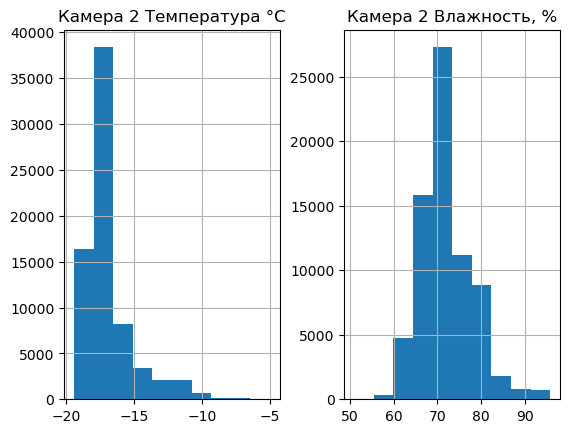

In [20]:
train1[[c for c in train1.columns if not c.startswith('miss_')]].hist()

array([[<Axes: title={'center': 'Камера 2 Температура °С'}>,
        <Axes: title={'center': 'Камера 2 Влажность, %'}>]], dtype=object)

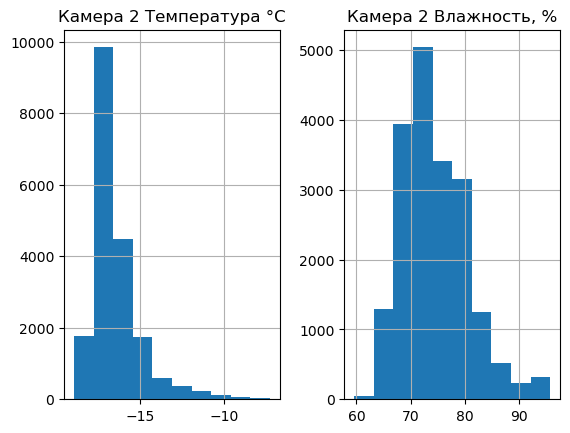

In [21]:
test1[[c for c in test1.columns if not c.startswith('miss_')]].hist()

In [22]:
train1_post = add_target_column1(train1)
val1_post = add_target_column1(val1)
test1_post = add_target_column1(test1)

In [23]:
min_len, median_len = get_anomaly_lengths_time(train1_post)
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

3 3 20 5


In [24]:
train1_post.to_csv('data_post/supervised/1/train.csv')
val1_post.to_csv('data_post/supervised/1/val.csv')
test1_post.to_csv('data_post/supervised/1/test.csv')

In [25]:
print(train1_post['target'].sum())
print(val1_post['target'].sum())
print(test1_post['target'].sum())

7112
4272
4278


In [ ]:
# ищем периоды длиннее 5 часов
df = df12.copy()
# Шаг 1: заполнение коротких пропусков (≤5 минут)
cols_to_fill = df.columns  # или выберите нужные
for col in cols_to_fill:
    is_nan = df[col].isna()
    groups = (is_nan != is_nan.shift()).cumsum()
    nan_groups = df[is_nan].groupby(groups[is_nan])
    for _, group in nan_groups:
        if len(group) <= 5:
            idx = group.index
            df.loc[idx, col] = df[col].interpolate(method='linear').loc[idx]

# Шаг 2: удаление строк с превышениями (уточните условие!)
mask_anomaly = (df['Камера 2 Температура °С'] >=-7) | (df['Камера 2 Влажность, %'] >= 80)
df = df[~mask_anomaly].copy()
df = df.set_index('Дата/время')

# Шаг 3: повторный asfreq для восстановления равномерной сетки
df = df.asfreq('1min')

# Шаг 4: поиск интервалов без пропусков длиной >5 часов
feature_columns = ['Камера 2 Температура °С', 'Камера 2 Влажность, %']  # замените на свои
valid_mask = df[feature_columns].notna().all(axis=1)
groups = (valid_mask != valid_mask.shift()).cumsum()
valid_groups = df[valid_mask].groupby(groups[valid_mask])

long_segments = []
for _, group in valid_groups:
    if len(group) > 300:  # >5 часов
        long_segments.append({
            'start': group.index[0],
            'end': group.index[-1],
            'length_min': len(group),
            'length_hours': len(group)/60
        })

segments_df = pd.DataFrame(long_segments)
print(segments_df)

                 start                 end  length_min  length_hours
0  2026-01-28 20:58:00 2026-01-29 03:11:00         374      6.233333
1  2026-01-29 03:34:00 2026-01-29 11:22:00         469      7.816667
2  2026-01-29 11:30:00 2026-01-29 19:19:00         470      7.833333
3  2026-01-29 19:30:00 2026-01-30 03:00:00         451      7.516667
4  2026-01-30 03:24:00 2026-01-30 10:44:00         441      7.350000
5  2026-01-30 11:19:00 2026-01-30 19:11:00         473      7.883333
6  2026-01-30 19:19:00 2026-01-31 02:34:00         436      7.266667
7  2026-01-31 12:35:00 2026-01-31 20:06:00         452      7.533333
8  2026-02-01 04:29:00 2026-02-01 11:53:00         445      7.416667
9  2026-02-01 21:22:00 2026-02-02 05:12:00         471      7.850000
10 2026-02-02 13:20:00 2026-02-02 20:24:00         425      7.083333
11 2026-02-03 05:12:00 2026-02-03 11:03:00         352      5.866667


In [ ]:
columns_to_check = df12.columns  # или ['col1', 'col2']

# Словарь для хранения результатов: {столбец: список интервалов}
gaps_info = {}

for col in columns_to_check:
    # Маска пропусков
    is_nan = df12[col].isna()
    
    # Идентифицируем смены состояния (переход от не-NaN к NaN и обратно)
    # Создаем метку группы: меняется при смене is_nan
    groups = (is_nan != is_nan.shift()).cumsum()
    
    # Группируем по группам и собираем информацию только для групп с NaN
    # groups[is_nan] выбирает только строки, где is_nan=True
    nan_groups = df12[is_nan].groupby(groups[is_nan])
    
    # Для каждой группы (последовательности NaN)
    intervals = []
    for _, group in nan_groups:
        length = len(group)  # количество минут в пропуске
        if length > 10:
            start = group.index[0]
            end = group.index[-1]
            intervals.append({
                'start': start,
                'end': end,
                'length_min': length,
                'column': col
            })
    
    if intervals:
        gaps_info[col] = pd.DataFrame(intervals)

# Вывод результатов
for col, df_gaps in gaps_info.items():
    print(f'\nСтолбец: {col}')
    print(df_gaps[['start', 'end', 'length_min']])


Столбец: Камера 2 Температура °С
    start    end  length_min
0     165    214          50
1     318    976         659
2     990   1336         347
3    1371   1382          12
4    1673   1727          55
5    2648   2717          70
6    2763   2793          31
7    3216   3226          11
8    3464   3487          24
9    4181   4210          30
10   4251   4278          28
11  11136  11212          77
12  11431  11466          36

Столбец: Примечание.2
    start    end  length_min
0       0   2424        2425
1    2434   3096         663
2    3104   3587         484
3    3599   4068         470
4    4082   4729         648
5    4733   5208         476
6    5273   5681         409
7    5703   8136        2434
8    8138   9132         995
9    9134  10901        1768
10  10903  19952        9050
11  19954  20234         281

Столбец: Камера 2 Влажность, %
    start    end  length_min
0     165    214          50
1     318    977         660
2     990   1336         347
3    1371   

In [ ]:
df = df11.copy()
# Вычисляем интервал между соседними записями
df['time_diff'] = df.index.diff()

# Определяем порог (например, 2 * медианный интервал)
threshold = 5

# Создаём метку нового сегмента там, где разрыв больше порога
df['segment'] = (df['time_diff'] > threshold).cumsum()

In [ ]:
df['segment'].value_counts()

segment
0    20235
Name: count, dtype: int64

In [14]:
# холодильные камеры
df11 = df1.iloc[:, :4]
df12 = df1.iloc[:, 4:8]
df13 = df1.iloc[:, 8:]

#df = df12.copy()
# убрать секунды
df11.index = df11.index.floor('min')
# удаление дубликатов
df11 = df11[~df11.index.duplicated(keep='first')]
# исправление некорректных значений(ошибки датчика)
df11.loc[(df11.iloc[:, 2] <= 0), 'Камера 1 Влажность, %'] = np.nan
df11.loc[(df11.iloc[:, 0] < -100)|(df11.iloc[:, 0] > 100)|(df11.iloc[:, 0] == 0), 'Камера 1 Температура °С'] = np.nan
# регулирование частоты
df11 = df11.asfreq('1min')
# интерполяция
df11 = df11.interpolate(method='linear')
df11 = df11.iloc[:, [0, 2]]
df11 = df11.reset_index()
#df11.to_csv('data_post/холодильная_камера1.csv')


# в числовой
df12['Камера 2 Влажность, %'] = pd.to_numeric(df12['Камера 2 Влажность, %'], errors='coerce')
# убрать секунды
df12.index = df12.index.floor('min')
# удаление дубликатов
df12 = df12[~df12.index.duplicated(keep='first')]
# исправление некорректных значений(ошибки датчика)
df12.loc[(df12.iloc[:, 2] <= 0), 'Камера 2 Влажность, %'] = np.nan
df12.loc[(df12.iloc[:, 0] < -100)|(df12.iloc[:, 0] > 100)|(df12.iloc[:, 0] == 0), 'Камера 2 Температура °С'] = np.nan
# регулирование частоты
df12 = df12.asfreq('1min')
# интерполяция
df12 = df12.interpolate(method='linear')
#df12 = df12.iloc[:, [0, 2]]
df12 = df12.reset_index()
#df12.to_csv('data_post/1/1.csv')


# убрать секунды
df13.index = df13.index.floor('min')
# удаление дубликатов
df13 = df13[~df13.index.duplicated(keep='first')]
# исправление некорректных значений(ошибки датчика)
df13.loc[(df13.iloc[:, 2] <= 0), 'Камера 3 Влажность, %'] = np.nan
df13.loc[(df13.iloc[:, 0] < -100)|(df13.iloc[:, 0] > 100)|(df13.iloc[:, 0] == 0), 'Камера 3 Температура °С'] = np.nan
# регулирование частоты
df13 = df13.asfreq('1min')
# интерполяция
df13 = df13.interpolate(method='linear')
df13 = df13.iloc[:, [0, 2]]
df13 = df13.reset_index()
#df13.to_csv('data_post/холодильная_камера3.csv')

C:\Users\al.melnikova\AppData\Local\Temp\ipykernel_2732\3037485614.py:17: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df11 = df11.interpolate(method='linear')
C:\Users\al.melnikova\AppData\Local\Temp\ipykernel_2732\3037485614.py:35: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df12 = df12.interpolate(method='linear')
C:\Users\al.melnikova\AppData\Local\Temp\ipykernel_2732\3037485614.py:51: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df13 = df13.interpolate(method='linear')


In [17]:
df12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20235 entries, 0 to 20234
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Дата/время               20235 non-null  datetime64[ns]
 1   Камера 2 Температура °С  20235 non-null  float64       
 2   Примечание.2             128 non-null    object        
 3   Камера 2 Влажность, %    20235 non-null  float64       
 4   Примечание.3             2967 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 790.6+ KB


In [15]:
df12.describe()

,Дата/время,Камера 2 Температура °С,"Камера 2 Влажность, %"
count,20235,20235.000000,20235.000000
mean,2026-01-30 13:15:00,-15.760373,71.813405
min,2026-01-23 12:38:00,-19.400000,51.000000
25%,2026-01-27 00:56:30,-17.400000,66.600000
50%,2026-01-30 13:15:00,-16.700000,70.300000
75%,2026-02-03 01:33:30,-14.600000,76.600000
max,2026-02-06 13:52:00,9.700000,95.700000
std,NaN,2.401298,7.187898


In [16]:
df1.iloc[:, 5].value_counts()

Примечание.2
Превышение температуры                          126
Какая-то ошибка датчика, причина не известна      5
Name: count, dtype: int64

In [10]:
df1.iloc[:, 7].value_counts()

Примечание.3
Превышение влажности                            2969
Какая-то ошибка дачтика                            3
Какая-то ошибка датчика, причина не известна       1
Name: count, dtype: int64

In [ ]:
# Создаём общий флаг аварии
df12['is_anomaly'] = ((df1['col1'] == 'Превышение температуры') | 
                    (df1['col3'] == 'Превышение влажности')).astype(int)

### 2 по сегментам

In [ ]:
#df2 = df2.drop('MAIN_WORDIN (MAIN_WORDIN)', axis=1)
#df2.set_index('Дата/время', inplace=True)
#df2.index = df2.index.floor('min')
#df2 = df2[~df2.index.duplicated(keep='first')]
# регулирование частоты
#df2 = df2.asfreq('1min')
#df2 = df2.interpolate(method='linear')
#df2 = df2.reset_index()
#df2.to_csv('data_post/котельная97_Мочилы_епанешников.csv')

In [7]:
# загрузка
train2 = pd.read_excel('data/unsupervised/2/2_train.xlsx', index_col=0)
test2 = pd.read_excel('data/unsupervised/2/2_test.xlsx', index_col=0)

#### исследование

In [8]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7299 entries, 2026-01-19 16:00:16 to 2026-01-23 19:59:45
Data columns (total 96 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Температура контура 1 (TE_KK1)                                7298 non-null   float64
 1   Температура контура 2 (TE_KK2)                                7298 non-null   float64
 2   Температура контура 3 (TE_KK3)                                7298 non-null   float64
 3   Уличная 1 (TE_UL1)                                            7298 non-null   float64
 4   Уличная 2 (TE_UL2)                                            7298 non-null   float64
 5   Уличная 3 (TE_UL3)                                            7298 non-null   float64
 6   Температура отопления 1 (TE_OT1)                              7298 non-null   float64
 7   Температура отопления 2 (TE_OT2) 

In [9]:
test2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2707 entries, 2026-01-19 10:00:51 to 2026-01-23 14:59:59
Data columns (total 96 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Температура контура 1 (TE_KK1)                                2706 non-null   float64
 1   Температура контура 2 (TE_KK2)                                2706 non-null   float64
 2   Температура контура 3 (TE_KK3)                                2706 non-null   float64
 3   Уличная 1 (TE_UL1)                                            2706 non-null   float64
 4   Уличная 2 (TE_UL2)                                            2706 non-null   float64
 5   Уличная 3 (TE_UL3)                                            2706 non-null   float64
 6   Температура отопления 1 (TE_OT1)                              2706 non-null   float64
 7   Температура отопления 2 (TE_OT2) 

In [ ]:
# проверка на разрывы
gaps = find_gaps_longer_than(
    test2,
    datetime_col='Дата/время',   # укажите ваш столбец
    freq='1min',
    threshold_min=5,
    columns_to_check=None,       # проверит все столбцы
    keep_datetime_index=True
)
# отдельно по каждому столбцу
if not gaps.empty:
    for col in gaps['column'].unique():
        print(f'\nСтолбец: {col}')
        print(gaps[gaps['column'] == col][['start', 'end', 'length_min']])
else:
    print(gaps)

In [ ]:
def split_by_gaps(df, gap_threshold='10min'):
    '''
    Разбивает DataFrame с DatetimeIndex на список непрерывных сегментов.

    Parameters
    ----------
    df : pd.DataFrame
        Данные с DatetimeIndex
    gap_threshold : str or pd.Timedelta
        Если разрыв между соседними timestamp больше этого значения,
        начинаем новый сегмент

    Returns
    -------
    list[pd.DataFrame]
    '''
    if df.empty:
        return []

    df = df.sort_index().copy()
    gap_threshold = pd.Timedelta(gap_threshold)

    time_diff = df.index.to_series().diff()
    segment_id = (time_diff > gap_threshold).cumsum()

    segments = [seg.copy() for _, seg in df.groupby(segment_id)]
    return segments

def preprocess_segment(segment, freq='1min', max_interp_gap='5min'):
    '''
    Предобработка одного непрерывного сегмента.
    '''
    segment = segment.copy()
    segment.index = segment.index.floor(freq)
    segment = segment.groupby(segment.index).mean()
    segment = segment.asfreq(freq)

    # интерполируем только короткие пропуски
    limit = int(pd.Timedelta(max_interp_gap) / pd.Timedelta(freq))
    segment = segment.interpolate(method='linear', limit=limit, limit_direction='both')

    return segment

In [ ]:
segments = split_by_gaps(train2, gap_threshold='5min')

train_processed_segments = []
for seg in segments:
    seg_proc = preprocess_segment(seg, freq='1min', max_interp_gap='5min')

    # можно выкинуть слишком короткие куски
    if len(seg_proc) >= 30:   # например sequence_len
        train_processed_segments.append(seg_proc)

In [142]:
for i in range(3):
    print(train_processed_segments[i].isna().sum().sum())

0
0
0


In [11]:
train2.describe()

,Температура контура 1 (TE_KK1),Температура контура 2 (TE_KK2),Температура контура 3 (TE_KK3),Уличная 1 (TE_UL1),Уличная 2 (TE_UL2),Уличная 3 (TE_UL3),Температура отопления 1 (TE_OT1),Температура отопления 2 (TE_OT2),Температура отопления 3 (TE_OT3),Уличная 1 (TE_U1),...,Задание температуры котлового контура (TE_KK_OUT),Задание температуры отопления (TE_OT_out),Клапан ГВС закрыт (VLV_GVS_ZSC),Клапан ГВС открыт (VLV_GVS_ZSO),Клапан ОТ закрыт (VLV_OT_ZSC),Клапан ОТ открыт (VLV_OT_ZSO),Температура ГВС (TE_GVS),Температура отопления (TE_OT),Температура котлового контура (TE_KK),Уличная температура (UL_TE)
count,7298.0,7298.0,7298.0,7298.0,7298.0,7298.0,7298.0,7298.0,7298.0,7298.0,...,4409.000000,4409.000000,4409.000000,4409.000000,4409.0,4409.000000,4409.000000,4409.000000,4409.000000,4409.000000
mean,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,72.603584,67.731708,0.858244,0.066228,0.0,0.010433,62.326355,67.899909,79.298072,-7.789499
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.074275,3.516871,0.348839,0.248709,0.0,0.101620,2.495016,3.798358,4.047942,2.605652
min,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,67.300000,61.000000,0.000000,0.000000,0.0,0.000000,47.800000,59.700000,70.100000,-17.800000
25%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,71.100000,65.900000,1.000000,0.000000,0.0,0.000000,61.100000,65.700000,76.500000,-8.700000
50%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,71.900000,66.900000,1.000000,0.000000,0.0,0.000000,62.200000,67.300000,79.000000,-7.200000
75%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,73.600000,69.100000,1.000000,0.000000,0.0,0.000000,63.400000,69.300000,81.400000,-6.500000
max,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,84.800000,80.800000,1.000000,1.000000,0.0,1.000000,71.100000,81.800000,94.400000,-3.100000


In [ ]:
segments = split_by_gaps(test2, gap_threshold='5min')

test_processed_segments = []
for seg in segments:
    seg_proc = preprocess_segment(seg, freq='1min', max_interp_gap='5min')

    # можно выкинуть слишком короткие куски
    if len(seg_proc) >= 30:   # например sequence_len
        test_processed_segments.append(seg_proc)\
        
test_processed_segments[0]['MAIN_WORDIN (MAIN_WORDIN)'] = 0

In [13]:
print(train2.isna().sum().sum())
#print(val2.isna().sum().sum())
print(test2.isna().sum().sum())

222556
79302


In [145]:
test_processed_segments[0].describe()

,Температура контура 1 (TE_KK1),Температура контура 2 (TE_KK2),Температура контура 3 (TE_KK3),Уличная 1 (TE_UL1),Уличная 2 (TE_UL2),Уличная 3 (TE_UL3),Температура отопления 1 (TE_OT1),Температура отопления 2 (TE_OT2),Температура отопления 3 (TE_OT3),Уличная 1 (TE_U1),...,Задание температуры котлового контура (TE_KK_OUT),Задание температуры отопления (TE_OT_out),Клапан ГВС закрыт (VLV_GVS_ZSC),Клапан ГВС открыт (VLV_GVS_ZSO),Клапан ОТ закрыт (VLV_OT_ZSC),Клапан ОТ открыт (VLV_OT_ZSO),Температура ГВС (TE_GVS),Температура отопления (TE_OT),Температура котлового контура (TE_KK),Уличная температура (UL_TE)
count,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,300.0,...,300.00000,300.000000,300.000000,300.000000,300.0,300.0,300.000000,300.000000,300.000000,300.000000
mean,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,72.23100,67.390333,0.670000,0.270000,0.0,0.0,60.360333,67.455833,79.005000,-7.501667
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.32093,1.714967,0.470998,0.444701,0.0,0.0,2.743428,2.263139,3.012839,1.184013
min,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,69.90000,64.400000,0.000000,0.000000,0.0,0.0,52.300000,62.200000,73.300000,-9.900000
25%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,71.20000,66.100000,0.000000,0.000000,0.0,0.0,58.800000,65.800000,76.500000,-8.325000
50%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,71.90000,66.900000,1.000000,0.000000,0.0,0.0,61.100000,67.400000,79.100000,-7.200000
75%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,73.12500,68.600000,1.000000,1.000000,0.0,0.0,62.400000,69.100000,81.400000,-6.600000
max,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,75.00000,70.900000,1.000000,1.000000,0.0,0.0,66.100000,72.900000,85.700000,-5.400000


In [ ]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test_labeled_segments = []

for seg in test_processed_segments:
    seg_labeled = add_target_column(
        seg,
        anomaly_intervals=list2,
        target_col_name='target',
        inclusive='both'
    )
    test_labeled_segments.append(seg_labeled)

test2_post = pd.concat(test_labeled_segments).sort_index()

In [369]:
test2_post = add_target_column(test2, anomaly_intervals=list2, target_col_name='target', inclusive='both')

In [370]:
test2_post['target'].sum()

304

In [991]:
#train3.to_csv('data_post/3/train3_post.csv')
#val3.to_csv('data_post/3/val3_post.csv')
#test3_post.to_csv('data_post/3/test3_post.csv')

#### обучение

In [ ]:
def scale_segment(segment, scaler, feature_names):
    scaled_values = scaler.transform(segment[feature_names])
    scaled_df = pd.DataFrame(
        scaled_values,
        index=segment.index,
        columns=feature_names
    )

    # target возвращаем обратно, если он есть
    if 'target' in segment.columns:
        scaled_df['target'] = segment['target'].values

    return scaled_df

In [ ]:
# объединяем train-сегменты только для fit scaler
train_concat = pd.concat(train_processed_segments[:2]).sort_index()

scaler = RobustScaler()
scaler.fit(train_concat)
feature_names = list(train_concat.columns)

train_scaled = scaler.transform(train_processed_segments[1])
val_scaled = scaler.transform(train_processed_segments[2])
test_scaled_segments = [scale_segment(seg, scaler, feature_names) for seg in test_labeled_segments]

# в датафрейм
train_norm = pd.DataFrame(train_scaled, index=train_processed_segments[1].index, columns=feature_names)
val_norm = pd.DataFrame(val_scaled, index=train_processed_segments[2].index, columns=feature_names)
test_norm1 = pd.DataFrame(test_scaled_segments[0], index=test_processed_segments[0].index, columns=feature_names)
test_norm2 = pd.DataFrame(test_scaled_segments[1], index=test_processed_segments[1].index, columns=feature_names)
test_norm3 = pd.DataFrame(test_scaled_segments[2], index=test_processed_segments[2].index, columns=feature_names)

# преобразование в TimeSeries
train_data = TimeSeries.from_pd(train_norm)
val_data = TimeSeries.from_pd(val_norm)
test_data1 = TimeSeries.from_pd(test_norm1)
test_data2 = TimeSeries.from_pd(test_norm2)
test_data3 = TimeSeries.from_pd(test_norm3)

y_true1 = test_labeled_segments[0]['target'].astype(int)
y_true2 = test_labeled_segments[1]['target'].astype(int)
y_true3 = test_labeled_segments[2]['target'].astype(int)
y_true_ts1 = TimeSeries.from_pd(test_labeled_segments[0][['target']])
y_true_ts2 = TimeSeries.from_pd(test_labeled_segments[1][['target']])
y_true_ts3 = TimeSeries.from_pd(test_labeled_segments[2][['target']])

In [994]:
# AE конфиг + обучение

# фиксация параметра
set_seed(42)

config = AutoEncoderConfig(
    sequence_len=30,
    hidden_size=16,
    layer_sizes=(128, 64, 32),
    num_epochs=20,
    batch_size=128,
    learning_rate=1e-3,
    transform=None,
    threshold=None
)

# обучение с отслеживанием времени
start_train = time.perf_counter()
model = AutoEncoder(config)
model.train(train_data)
train_time_sec = time.perf_counter() - start_train

 |========================================| 100.0% Complete, Loss 0.0004


In [998]:
# расчёт скоров с отслеживанием времени
start_infer = time.perf_counter()
val_score_ts = model.get_anomaly_score(val_data).to_pd().iloc[:, 0]
test_score_ts1 = model.get_anomaly_score(test_data1).to_pd().iloc[:, 0]
test_score_ts2 = model.get_anomaly_score(test_data2).to_pd().iloc[:, 0]
test_score_ts3 = model.get_anomaly_score(test_data3).to_pd().iloc[:, 0]
inference_time_sec = time.perf_counter() - start_infer

# порог
q = 0.9
threshold = float(val_score_ts.quantile(q))

# с учётом порога
y_pred1 = (test_score_ts1 > threshold).astype(int)
y_pred2 = (test_score_ts2 > threshold).astype(int)
y_pred3 = (test_score_ts3 > threshold).astype(int)

test_score_ts = pd.concat([test_score_ts1, test_score_ts2, test_score_ts3]).sort_index()
y_true = pd.concat([test_labeled_segments[0][['target']], test_labeled_segments[1][['target']], test_labeled_segments[2][['target']]]).sort_index()
y_pred = pd.concat([y_pred1, y_pred2, y_pred3]).sort_index()

In [ ]:
# point-level метрики
f1_val = f1_at_fpr(y_true, test_score_ts, target_fpr=0.05)
p100 = precision_at_k(y_true, test_score_ts, k=100)
r100 = recall_at_k(y_true, test_score_ts, k=100)
pr_auc_val = pr_auc(y_true, test_score_ts)

# метрики событий
y_pred_bin = pd.Series((np.asarray(test_score_ts) >= threshold).astype(int), index=y_true.index)
pred_events = binary_to_events(y_pred_bin, gap_minutes=10, min_len_minutes=5)
true_events = binary_to_events(y_true, gap_minutes=10, min_len_minutes=5)

event_r = event_recall(true_events, pred_events, max_hours=4)
event_p = event_precision(true_events, pred_events, max_hours=4)
ttd_list = time_to_detect(true_events, pred_events, reduction='list', unit='minutes', max_hours=4)
ttd_mean = time_to_detect(true_events, pred_events, reduction='mean', unit='minutes', max_hours=4)
ttd_median = time_to_detect(true_events, pred_events, reduction='median', unit='minutes', max_hours=4)
alerts = alerts_per_day(pred_events, y_true.index)

# параметры модели
model_params = config.__dict__

In [ ]:
true_events = binary_to_events(y_true, gap_minutes=10, min_len_minutes=5)
pred_events = binary_to_events(y_pred, gap_minutes=10, min_len_minutes=5)

print('PR-AUC:', pr_auc(y_true, test_score_ts))
print('F1 @ FPR=1%:', f1_at_fpr(y_true, test_score_ts, target_fpr=0.05))
print('Precision@100:', precision_at_k(y_true, test_score_ts, k=100))
print('Recall@100:', recall_at_k(y_true, test_score_ts, k=100))
print('Event Recall:', event_recall(true_events, pred_events, max_hours=5))
print('Event Precision:', event_precision(true_events, pred_events, max_hours=5))
print('Time-to-detect mean (minutes):', time_to_detect(true_events, pred_events, reduction='mean', unit='minutes', max_hours=5))
print('Time-to-detect median (minutes):', time_to_detect(true_events, pred_events, reduction='median', unit='minutes', max_hours=5))
print('Time-to-detect list (minutes):', time_to_detect(true_events, pred_events, reduction='list', unit='minutes', max_hours=5))
print('Alerts per day:', alerts_per_day(pred_events, y_true.index))
print('n true events:', len(true_events))
print('n pred events:', len(pred_events))
print(confusion_matrix(y_true, y_pred))

PR-AUC: 0.2942713767815345
F1 @ FPR=1%: 0.0
Precision@100: 0.0
Recall@100: 0.0
Event Recall: 0.3333333333333333
Event Precision: 0.5
Time-to-detect mean (minutes): 211.0
Time-to-detect median (minutes): 211.0
Time-to-detect list (minutes): [-211.0]
Alerts per day: 0.4753259613797656
n true events: 3
n pred events: 2
[[738 699]
 [ 82 222]]


In [ ]:
# добавление в таблицу
add_results(
    df=results,
    model_name='AutoEncoder_Merlion',
    pr_auc=pr_auc_val,
    f1_at_fpr_1=f1_val,
    precision_at_100=p100,
    recall_at_100=r100,
    event_recall=event_r,
    event_precision=event_p,
    ttd_mean = ttd_mean,
    ttd_median = ttd_median,
    alerts = alerts_per_day(pred_events, y_true.index),
    n_true_events=len(true_events),
    n_pred_events=len(pred_events),
    train_time_sec=train_time_sec,
    inference_time_sec=inference_time_sec,
    model_params=model_params,
)

results.to_excel('2_results.xlsx', index=True)

In [ ]:
# график событий
fig = go.Figure()

# true events
for start, end in true_events:
    fig.add_trace(
        go.Scatter(
            x=[start, end],
            y=[1, 1],
            mode='lines',
            line=dict(width=12, color='green'),
            name='true_event',
            showlegend=False
        )
    )

    # линия начала true события
    fig.add_vline(
        x=start,
        line_width=2,
        line_dash='dash',
        line_color='green',
        opacity=0.7
    )

# predicted events
for start, end in pred_events:
    fig.add_trace(
        go.Scatter(
            x=[start, end],
            y=[0, 0],
            mode='lines',
            line=dict(width=12, color='red'),
            name='pred_event',
            showlegend=False
        )
    )

    # линия начала pred события
    fig.add_vline(
        x=start,
        line_width=2,
        line_dash='dot',
        line_color='red',
        opacity=0.7
    )

fig.update_layout(
    yaxis=dict(
        tickvals=[0,1],
        ticktext=['pred','true']
    ),
    title='True vs Predicted Events',
    template='plotly_white',
    height=300
)

fig.show()

#### оптимизация

In [ ]:
#import optuna

# ВАЖНО: эти функции у тебя уже есть:
# - pick_threshold_by_false_alarms_day(...)
# - false_alarms_per_day_from_scores(...)
# - binary_to_events(...) (используется внутри)
#
# Также у тебя уже есть:
# train_data, val_data (TimeSeries)
# model = AutoEncoder(config) из Merlion

#def objective(trial):
    # -----------------------
    # 1) Sample hyperparams
    # -----------------------
#    hidden_size = trial.suggest_int('hidden_size', 8, 64)
#    num_epochs  = trial.suggest_int('num_epochs', 10, 120)
#    batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
#    lr          = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)

    # пример для layer_sizes (подстрой под то, что принимает AutoEncoderConfig)
#    l1 = trial.suggest_int('l1', 16, 128)
#    l2 = trial.suggest_int('l2', 16, 256)
#    l3 = trial.suggest_int('l3', 16, 256)
#    layer_sizes = (l1, l2, l3)

    # пост-агрегация событий (фиксируем для честного сравнения)
#    gap_minutes = 2
#    min_event_len_minutes = 2

    # эксплуатационный лимит (его не оптимизируем, фиксируем)
#    max_fa_day = 1.0  # например: <= 1 ложного события/сутки на норме

    # вес за 'качество нормы'
    # чем больше lambda_norm, тем сильнее Optuna будет 'стягивать' score на норме вниз
#    lambda_norm = 0.1

    # -----------------------
    # 2) Train model
    # -----------------------
#    config = AutoEncoderConfig(
#        hidden_size=hidden_size,
#        layer_sizes=layer_sizes,
#        sequence_len=5,
#        num_epochs=num_epochs,
#        batch_size=batch_size,
#        learning_rate=lr,
#        transform=None,
#        threshold=None  # порог выбираем отдельно
#    )

#    model = AutoEncoder(config)
#    model.train(train_data)

    # -----------------------
    # 3) Scores on normal-only val
    # -----------------------
#    val_scores = model.get_anomaly_score(val_data).to_pd().squeeze()
#    val_scores = val_scores.astype(float).dropna().sort_index()

    # защита от странных trial-ов
#    if val_scores.empty or not np.isfinite(val_scores.values).all():
#        return 1e6

    # -----------------------
    # 4) Threshold protocol: pick thr s.t. FA/day <= max_fa_day
    # -----------------------
#    thr, fa_day = pick_threshold_by_false_alarms_day(
#        val_scores,
#        max_false_alarms_day=max_fa_day,
#        gap_minutes=gap_minutes,
#        min_event_len_minutes=min_event_len_minutes
#    )

    # если модель слишком шумная и не удаётся подобрать порог под ограничение
#    if thr is None or fa_day is None or np.isnan(fa_day):
#        return 1e6

    # -----------------------
    # 5) 'Normal fit' proxy
    # -----------------------
    # На норме чем меньше score (ошибка реконструкции/аномальности), тем лучше.
    # Используем robust статистику, чтобы не ловить единичные выбросы.
#    norm_proxy = float(np.median(val_scores.values))  # можно mean, но median стабильнее

    # -----------------------
    # 6) Combined objective
    # -----------------------
    # Минимизируем: (FA/day) + lambda * median(score)
    # FA/day уже 'в пределах' лимита, но Optuna будет искать ещё меньше FA/day и лучше fit нормы
#    loss = float(fa_day) + float(lambda_norm) * norm_proxy

    # логируем полезные штуки в trial
#    trial.set_user_attr('thr', float(thr))
#    trial.set_user_attr('fa_day', float(fa_day))
#    trial.set_user_attr('val_score_median', float(norm_proxy))

#    return loss


#study = optuna.create_study(direction='minimize')
#study.optimize(objective, n_trials=30)

#print('Best loss:', study.best_value)
#print('Best params:', study.best_params)
#print('Best trial attrs:', study.best_trial.user_attrs)

### 2

In [65]:
# загрузка
train4 = pd.read_excel('data/supervised/4/train.xlsx', index_col=0)
test4 = pd.read_excel('data/supervised/4/test.xlsx', index_col=0)

In [24]:
train4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7966 entries, 2026-02-06 09:48:28 to 2026-02-10 17:59:31
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Давление обратки сети (A3)                  7966 non-null   float64
 1   Давление подачи сети (A2)                   7966 non-null   float64
 2   Текущая температура улицы (p01)             7966 non-null   int64  
 3   Температура обратки сети (A1)               7966 non-null   float64
 4   Температура подачи сети (A0)                7966 non-null   float64
 5   Уставка температуры подачи по погоде (A60)  7966 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 435.6 KB


In [25]:
test4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3015 entries, 2026-02-10 18:00:18 to 2026-02-12 09:47:55
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Давление обратки сети (A3)                  3015 non-null   float64
 1   Давление подачи сети (A2)                   3015 non-null   float64
 2   Текущая температура улицы (p01)             3015 non-null   int64  
 3   Температура обратки сети (A1)               3015 non-null   float64
 4   Температура подачи сети (A0)                3015 non-null   float64
 5   Уставка температуры подачи по погоде (A60)  3015 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 164.9 KB


In [26]:
min_len, median_len = event_lengths(list4)['min'], event_lengths(list4)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 14 64 32


In [66]:
freq_data = '1min'
train4, val4, train_col = preprocess(train4, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test4 = preprocess(test4, freq=freq_data, max_interp_gap=gap_fill)

Выбросы не найдены
Выбросы не найдены


In [37]:
for i in range(0, train4.shape[1], 30):
    print((train4.columns[i:i+30] ==test4.columns[i:i+30]).sum() == len(train4.columns[i:i+30] ==test4.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [38]:
print(train4.shape, val4.shape, test4.shape)

(5001, 13) (1251, 13) (2388, 13)


In [67]:
print(train4['miss_all'].sum())
print(val4['miss_all'].sum())
print(test4['miss_all'].sum())

68
30
60


In [40]:
print(train4.isna().sum().sum())
print(val4.isna().sum().sum())
print(test4.isna().sum().sum())

0
0
0


In [41]:
train4[[c for c in train4.columns if not c.startswith('miss_')]].describe()

,Давление обратки сети (A3),Давление подачи сети (A2),Текущая температура улицы (p01),Температура обратки сети (A1),Температура подачи сети (A0),Уставка температуры подачи по погоде (A60)
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,2.831651,3.259337,10.154489,49.338004,60.404542,58.700587
std,0.068172,0.068105,6.555538,2.088341,4.942400,4.155622
min,2.550000,3.000000,0.000000,44.900000,48.200000,49.400000
25%,2.800000,3.200000,4.000000,47.750000,56.250000,56.200000
50%,2.800000,3.300000,10.000000,48.800000,60.450000,57.600000
75%,2.900000,3.300000,15.000000,50.500000,64.100000,60.800000
max,3.200000,3.600000,22.000000,54.500000,74.600000,66.400000


In [42]:
test4[[c for c in test4.columns if not c.startswith('miss_')]].describe()

,Давление обратки сети (A3),Давление подачи сети (A2),Текущая температура улицы (p01),Температура обратки сети (A1),Температура подачи сети (A0),Уставка температуры подачи по погоде (A60)
count,2388.000000,2388.000000,2388.000000,2388.000000,2388.000000,2388.000000
mean,2.782307,3.180025,5.342382,49.188138,59.833186,58.071905
std,0.336497,0.382869,4.155430,1.652254,4.651281,2.378675
min,0.000000,0.000000,0.000000,44.450000,48.300000,47.800000
25%,2.800000,3.200000,1.000000,48.700000,56.500000,57.400000
50%,2.800000,3.200000,5.000000,49.600000,59.550000,58.300000
75%,2.900000,3.300000,9.000000,50.100000,63.500000,59.400000
max,3.000000,3.400000,14.000000,51.900000,71.200000,62.200000


array([[<Axes: title={'center': 'Давление обратки сети (A3)'}>,
        <Axes: title={'center': 'Давление подачи сети (A2)'}>],
       [<Axes: title={'center': 'Текущая температура улицы (p01)'}>,
        <Axes: title={'center': 'Температура обратки сети (A1)'}>],
       [<Axes: title={'center': 'Температура подачи сети (A0)'}>,
        <Axes: title={'center': 'Уставка температуры подачи по погоде (A60)'}>]],
      dtype=object)

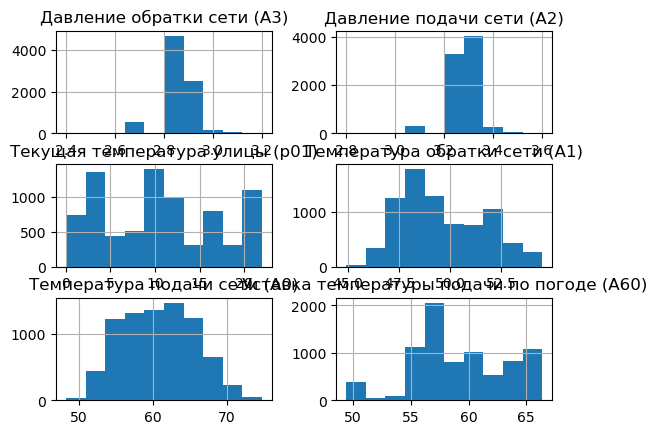

In [45]:
train4[[c for c in train4.columns if not c.startswith('miss_')]].hist()

array([[<Axes: title={'center': 'Давление обратки сети (A3)'}>,
        <Axes: title={'center': 'Давление подачи сети (A2)'}>],
       [<Axes: title={'center': 'Текущая температура улицы (p01)'}>,
        <Axes: title={'center': 'Температура обратки сети (A1)'}>],
       [<Axes: title={'center': 'Температура подачи сети (A0)'}>,
        <Axes: title={'center': 'Уставка температуры подачи по погоде (A60)'}>]],
      dtype=object)

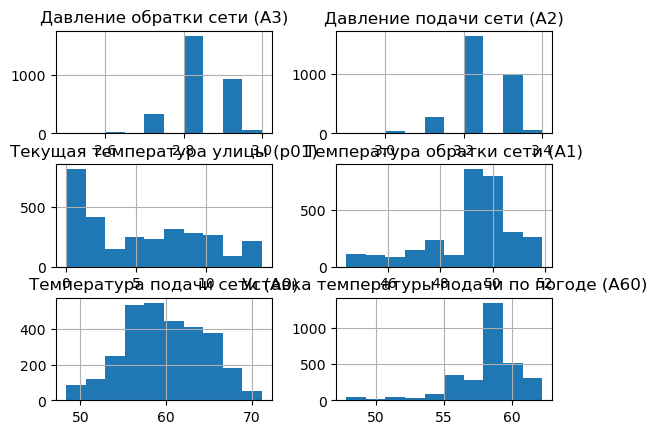

In [46]:
test4[[c for c in test4.columns if not c.startswith('miss_')]].hist()

In [68]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
train4_post = add_target_column(
    train4,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
val4_post = add_target_column(
    val4,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test4_post = add_target_column(
    test4,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [69]:
print(train4_post['target'].sum())
print(val4_post['target'].sum())
print(test4_post['target'].sum())

30
87
82


In [70]:
train4_post.to_csv('data_post/supervised/4/train.csv')
val4_post.to_csv('data_post/supervised/4/val.csv')
test4_post.to_csv('data_post/supervised/4/test.csv')

#### исследование

In [36]:
# загрузка
train2 = pd.read_excel('data/unsupervised/2/2_train.xlsx', index_col=0)
test21 = pd.read_excel('data/unsupervised/2/2_test1.xlsx', index_col=0)
test22 = pd.read_excel('data/unsupervised/2/2_test2.xlsx', index_col=0)
test23 = pd.read_excel('data/unsupervised/2/2_test3.xlsx', index_col=0)

In [11]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7299 entries, 2026-01-19 16:00:16 to 2026-01-23 19:59:45
Data columns (total 96 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Температура контура 1 (TE_KK1)                                7298 non-null   float64
 1   Температура контура 2 (TE_KK2)                                7298 non-null   float64
 2   Температура контура 3 (TE_KK3)                                7298 non-null   float64
 3   Уличная 1 (TE_UL1)                                            7298 non-null   float64
 4   Уличная 2 (TE_UL2)                                            7298 non-null   float64
 5   Уличная 3 (TE_UL3)                                            7298 non-null   float64
 6   Температура отопления 1 (TE_OT1)                              7298 non-null   float64
 7   Температура отопления 2 (TE_OT2) 

In [16]:
test21.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 436 entries, 2026-01-19 10:00:51 to 2026-01-19 14:59:19
Data columns (total 96 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Температура контура 1 (TE_KK1)                                436 non-null    float64
 1   Температура контура 2 (TE_KK2)                                436 non-null    float64
 2   Температура контура 3 (TE_KK3)                                436 non-null    float64
 3   Уличная 1 (TE_UL1)                                            436 non-null    float64
 4   Уличная 2 (TE_UL2)                                            436 non-null    float64
 5   Уличная 3 (TE_UL3)                                            436 non-null    float64
 6   Температура отопления 1 (TE_OT1)                              436 non-null    float64
 7   Температура отопления 2 (TE_OT2)  

In [26]:
min_len, median_len = event_lengths(list2)['min'], event_lengths(list2)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 36 64 32


In [37]:
freq_data = '1min'
train2, val2, train_col = preprocess(train2, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test21 = preprocess(test21, freq=freq_data, max_interp_gap=gap_fill, fit_dummy_columns=train_col)
test22 = preprocess(test22, freq=freq_data, max_interp_gap=gap_fill, fit_dummy_columns=train_col)
test23 = preprocess(test23, freq=freq_data, max_interp_gap=gap_fill, fit_dummy_columns=train_col)

In [40]:
for i in range(0, train2.shape[1], 30):
    print((train2.columns[i:i+30] ==test23.columns[i:i+30]).sum() == len(train2.columns[i:i+30] ==test23.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True
True
True
True
True
True
True


In [41]:
print(train2.shape, val2.shape, test21.shape, test22.shape, test23.shape)

(4800, 193) (1200, 193) (300, 193) (781, 193) (660, 193)


In [42]:
print(train2['miss_all'].sum())
print(val2['miss_all'].sum())
print(test21['miss_all'].sum())

914
677
10


In [43]:
print(train2.isna().sum().sum())
print(val2.isna().sum().sum())
print(test21.isna().sum().sum())

0
0
0


In [257]:
train2.describe()

,Температура контура 1 (TE_KK1),Температура контура 2 (TE_KK2),Температура контура 3 (TE_KK3),Уличная 1 (TE_UL1),Уличная 2 (TE_UL2),Уличная 3 (TE_UL3),Температура отопления 1 (TE_OT1),Температура отопления 2 (TE_OT2),Температура отопления 3 (TE_OT3),Уличная 1 (TE_U1),...,miss_Задание температуры котлового контура (TE_KK_OUT),miss_Задание температуры отопления (TE_OT_out),miss_Клапан ГВС закрыт (VLV_GVS_ZSC),miss_Клапан ГВС открыт (VLV_GVS_ZSO),miss_Клапан ОТ закрыт (VLV_OT_ZSC),miss_Клапан ОТ открыт (VLV_OT_ZSO),miss_Температура ГВС (TE_GVS),miss_Температура отопления (TE_OT),miss_Температура котлового контура (TE_KK),miss_Уличная температура (UL_TE)
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.00000,4800.000000,...,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,79.839583,63.031250,46.222917,-21.850833,-8.404167,6.723333,76.477917,59.669583,37.81875,-21.850833,...,0.190417,0.190417,0.190417,0.190417,0.190417,0.190417,0.190417,0.190417,0.190417,0.190417
std,34.794447,27.469301,20.144154,9.522691,3.662573,2.930059,33.329418,26.004271,16.48158,9.522691,...,0.392671,0.392671,0.392671,0.392671,0.392671,0.392671,0.392671,0.392671,0.392671,0.392671
min,0.000000,0.000000,0.000000,-26.000000,-10.000000,0.000000,0.000000,0.000000,0.00000,-26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,95.000000,75.000000,55.000000,-26.000000,-10.000000,8.000000,91.000000,71.000000,45.00000,-26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,95.000000,75.000000,55.000000,-26.000000,-10.000000,8.000000,91.000000,71.000000,45.00000,-26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,95.000000,75.000000,55.000000,-26.000000,-10.000000,8.000000,91.000000,71.000000,45.00000,-26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,95.000000,75.000000,55.000000,0.000000,0.000000,8.000000,91.000000,71.000000,45.00000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [258]:
test2.describe()

,Температура контура 1 (TE_KK1),Температура контура 2 (TE_KK2),Температура контура 3 (TE_KK3),Уличная 1 (TE_UL1),Уличная 2 (TE_UL2),Уличная 3 (TE_UL3),Температура отопления 1 (TE_OT1),Температура отопления 2 (TE_OT2),Температура отопления 3 (TE_OT3),Уличная 1 (TE_U1),...,miss_Задание температуры котлового контура (TE_KK_OUT),miss_Задание температуры отопления (TE_OT_out),miss_Клапан ГВС закрыт (VLV_GVS_ZSC),miss_Клапан ГВС открыт (VLV_GVS_ZSO),miss_Клапан ОТ закрыт (VLV_OT_ZSC),miss_Клапан ОТ открыт (VLV_OT_ZSO),miss_Температура ГВС (TE_GVS),miss_Температура отопления (TE_OT),miss_Температура котлового контура (TE_KK),miss_Уличная температура (UL_TE)
count,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,...,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000,6060.000000
mean,27.731848,21.893564,16.055281,-7.589769,-2.919142,2.335314,26.564191,20.725908,13.136139,-7.589769,...,0.722277,0.722277,0.722277,0.722277,0.722277,0.722277,0.722277,0.722277,0.722277,0.722277
std,43.194653,34.101042,25.007431,11.821695,4.546806,3.637444,41.375931,32.282320,20.460625,11.821695,...,0.447913,0.447913,0.447913,0.447913,0.447913,0.447913,0.447913,0.447913,0.447913,0.447913
min,0.000000,0.000000,0.000000,-26.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,-26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,-26.000000,-10.000000,0.000000,0.000000,0.000000,0.000000,-26.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,95.000000,75.000000,55.000000,0.000000,0.000000,8.000000,91.000000,71.000000,45.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,95.000000,75.000000,55.000000,0.000000,0.000000,8.000000,91.000000,71.000000,45.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [259]:
#train2.hist()

In [260]:
#test2.hist()

In [44]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test21_post = add_target_column(
    test21,
    anomaly_intervals=list2,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test22_post = add_target_column(
    test22,
    anomaly_intervals=list2,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test23_post = add_target_column(
    test23,
    anomaly_intervals=list2,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [46]:
print(test21_post['target'].sum())
print(test22_post['target'].sum())
print(test23_post['target'].sum())

74
148
82


In [47]:
train2.to_csv('data_post/unsupervised/2/train.csv')
val2.to_csv('data_post/unsupervised/2/val.csv')
test21_post.to_csv('data_post/unsupervised/2/test1.csv')
test22_post.to_csv('data_post/unsupervised/2/test2.csv')
test23_post.to_csv('data_post/unsupervised/2/test3.csv')

#### для подбора гиперпараметров

In [180]:
# загрузка
train2_optuna = pd.read_excel('data/2/2_train.xlsx', index_col=0)
val2_optuna = pd.read_excel('data/2/val2_optuna.xlsx', index_col=0)
test2_optuna = pd.read_excel('data/2/test2_optuna.xlsx', index_col=0)

In [176]:
print(train2_optuna.shape)
print(val2_optuna.shape)
print(test2_optuna.shape)

(7299, 96)
(436, 96)
(2271, 96)


In [75]:
train2_optuna.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7299 entries, 2026-01-19 16:00:16 to 2026-01-23 19:59:45
Data columns (total 96 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Температура контура 1 (TE_KK1)                                7298 non-null   float64
 1   Температура контура 2 (TE_KK2)                                7298 non-null   float64
 2   Температура контура 3 (TE_KK3)                                7298 non-null   float64
 3   Уличная 1 (TE_UL1)                                            7298 non-null   float64
 4   Уличная 2 (TE_UL2)                                            7298 non-null   float64
 5   Уличная 3 (TE_UL3)                                            7298 non-null   float64
 6   Температура отопления 1 (TE_OT1)                              7298 non-null   float64
 7   Температура отопления 2 (TE_OT2) 

In [76]:
test2_optuna.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2271 entries, 2026-01-20 03:59:01 to 2026-01-23 14:59:59
Data columns (total 96 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Температура контура 1 (TE_KK1)                                2270 non-null   float64
 1   Температура контура 2 (TE_KK2)                                2270 non-null   float64
 2   Температура контура 3 (TE_KK3)                                2270 non-null   float64
 3   Уличная 1 (TE_UL1)                                            2270 non-null   float64
 4   Уличная 2 (TE_UL2)                                            2270 non-null   float64
 5   Уличная 3 (TE_UL3)                                            2270 non-null   float64
 6   Температура отопления 1 (TE_OT1)                              2270 non-null   float64
 7   Температура отопления 2 (TE_OT2) 

In [177]:
# список блоков аномалий
list2 = [['2026-01-19 13:31', '2026-01-19 14:44'], ['2026-01-20 09:02', '2026-01-20 11:29'], ['2026-01-23 08:54', '2026-01-23 10:15']]

min_len, median_len = event_lengths(list2)['min'], event_lengths(list2)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)

In [181]:
freq_data = '1min'
train2_optuna, train_col = preprocess(train2_optuna, freq=freq_data, max_interp_gap=gap_fill, return_dummy_columns=True)
val2_optuna = preprocess(val2_optuna, freq=freq_data, max_interp_gap=gap_fill, fit_dummy_columns=train_col)
test2_optuna = preprocess(test2_optuna, freq=freq_data, max_interp_gap=gap_fill)

In [182]:
print(train2_optuna.shape, val2_optuna.shape, test2_optuna.shape)

(6000, 193) (300, 193) (4981, 193)


In [183]:
print(train2_optuna['miss_all'].sum())
print(val2_optuna['miss_all'].sum())
print(test2_optuna['miss_all'].sum())

1591
10
3588


In [184]:
train2_optuna.describe()

,Температура контура 1 (TE_KK1),Температура контура 2 (TE_KK2),Температура контура 3 (TE_KK3),Уличная 1 (TE_UL1),Уличная 2 (TE_UL2),Уличная 3 (TE_UL3),Температура отопления 1 (TE_OT1),Температура отопления 2 (TE_OT2),Температура отопления 3 (TE_OT3),Уличная 1 (TE_U1),...,miss_Задание температуры котлового контура (TE_KK_OUT),miss_Задание температуры отопления (TE_OT_out),miss_Клапан ГВС закрыт (VLV_GVS_ZSC),miss_Клапан ГВС открыт (VLV_GVS_ZSO),miss_Клапан ОТ закрыт (VLV_OT_ZSC),miss_Клапан ОТ открыт (VLV_OT_ZSO),miss_Температура ГВС (TE_GVS),miss_Температура отопления (TE_OT),miss_Температура котлового контура (TE_KK),miss_Уличная температура (UL_TE)
count,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,6000.0,...,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.265167,0.265167,0.265167,0.265167,0.265167,0.265167,0.265167,0.265167,0.265167,0.265167
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.441459,0.441459,0.441459,0.441459,0.441459,0.441459,0.441459,0.441459,0.441459,0.441459
min,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [185]:
test2_optuna.describe()

,Температура контура 1 (TE_KK1),Температура контура 2 (TE_KK2),Температура контура 3 (TE_KK3),Уличная 1 (TE_UL1),Уличная 2 (TE_UL2),Уличная 3 (TE_UL3),Температура отопления 1 (TE_OT1),Температура отопления 2 (TE_OT2),Температура отопления 3 (TE_OT3),Уличная 1 (TE_U1),...,miss_Задание температуры котлового контура (TE_KK_OUT),miss_Задание температуры отопления (TE_OT_out),miss_Клапан ГВС закрыт (VLV_GVS_ZSC),miss_Клапан ГВС открыт (VLV_GVS_ZSO),miss_Клапан ОТ закрыт (VLV_OT_ZSC),miss_Клапан ОТ открыт (VLV_OT_ZSO),miss_Температура ГВС (TE_GVS),miss_Температура отопления (TE_OT),miss_Температура котлового контура (TE_KK),miss_Уличная температура (UL_TE)
count,4981.0,4981.0,4981.0,4981.0,4981.0,4981.0,4981.0,4981.0,4981.0,4981.0,...,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.720337,0.720337,0.720337,0.720337,0.720337,0.720337,0.720337,0.720337,0.720337,0.720337
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.448879,0.448879,0.448879,0.448879,0.448879,0.448879,0.448879,0.448879,0.448879,0.448879
min,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,95.0,75.0,55.0,-26.0,-10.0,8.0,91.0,71.0,45.0,-26.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#train2.hist()

In [ ]:
#test2.hist()

In [186]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
val2_optuna = add_target_column(
    val2_optuna,
    anomaly_intervals=list2,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

test2_optuna = add_target_column(
    test2_optuna,
    anomaly_intervals=list2,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [225]:
test2_optuna['target'].sum()

230

In [ ]:
#train2_optuna.to_csv('data_post/2/train2_optuna.csv')
#val2_optuna.to_csv('data_post/2/val2_optuna.csv')
#test2_optuna.to_csv('data_post/2/test2_optuna.csv')

#### оптимизация

In [ ]:
#import optuna

# ВАЖНО: эти функции у тебя уже есть:
# - pick_threshold_by_false_alarms_day(...)
# - false_alarms_per_day_from_scores(...)
# - binary_to_events(...) (используется внутри)
#
# Также у тебя уже есть:
# train_data, val_data (TimeSeries)
# model = AutoEncoder(config) из Merlion

#def objective(trial):
    # -----------------------
    # 1) Sample hyperparams
    # -----------------------
#    hidden_size = trial.suggest_int('hidden_size', 8, 64)
#    num_epochs  = trial.suggest_int('num_epochs', 10, 120)
#    batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
#    lr          = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)

    # пример для layer_sizes (подстрой под то, что принимает AutoEncoderConfig)
#    l1 = trial.suggest_int('l1', 16, 128)
#    l2 = trial.suggest_int('l2', 16, 256)
#    l3 = trial.suggest_int('l3', 16, 256)
#    layer_sizes = (l1, l2, l3)

    # пост-агрегация событий (фиксируем для честного сравнения)
#    gap_minutes = 2
#    min_event_len_minutes = 2

    # эксплуатационный лимит (его не оптимизируем, фиксируем)
#    max_fa_day = 1.0  # например: <= 1 ложного события/сутки на норме

    # вес за 'качество нормы'
    # чем больше lambda_norm, тем сильнее Optuna будет 'стягивать' score на норме вниз
#    lambda_norm = 0.1

    # -----------------------
    # 2) Train model
    # -----------------------
#    config = AutoEncoderConfig(
#        hidden_size=hidden_size,
#        layer_sizes=layer_sizes,
#        sequence_len=5,
#        num_epochs=num_epochs,
#        batch_size=batch_size,
#        learning_rate=lr,
#        transform=None,
#        threshold=None  # порог выбираем отдельно
#    )

#    model = AutoEncoder(config)
#    model.train(train_data)

    # -----------------------
    # 3) Scores on normal-only val
    # -----------------------
#    val_scores = model.get_anomaly_score(val_data).to_pd().squeeze()
#    val_scores = val_scores.astype(float).dropna().sort_index()

    # защита от странных trial-ов
#    if val_scores.empty or not np.isfinite(val_scores.values).all():
#        return 1e6

    # -----------------------
    # 4) Threshold protocol: pick thr s.t. FA/day <= max_fa_day
    # -----------------------
#    thr, fa_day = pick_threshold_by_false_alarms_day(
#        val_scores,
#        max_false_alarms_day=max_fa_day,
#        gap_minutes=gap_minutes,
#        min_event_len_minutes=min_event_len_minutes
#    )

    # если модель слишком шумная и не удаётся подобрать порог под ограничение
#    if thr is None or fa_day is None or np.isnan(fa_day):
#        return 1e6

    # -----------------------
    # 5) 'Normal fit' proxy
    # -----------------------
    # На норме чем меньше score (ошибка реконструкции/аномальности), тем лучше.
    # Используем robust статистику, чтобы не ловить единичные выбросы.
#    norm_proxy = float(np.median(val_scores.values))  # можно mean, но median стабильнее

    # -----------------------
    # 6) Combined objective
    # -----------------------
    # Минимизируем: (FA/day) + lambda * median(score)
    # FA/day уже 'в пределах' лимита, но Optuna будет искать ещё меньше FA/day и лучше fit нормы
#    loss = float(fa_day) + float(lambda_norm) * norm_proxy

    # логируем полезные штуки в trial
#    trial.set_user_attr('thr', float(thr))
#    trial.set_user_attr('fa_day', float(fa_day))
#    trial.set_user_attr('val_score_median', float(norm_proxy))

#    return loss


#study = optuna.create_study(direction='minimize')
#study.optimize(objective, n_trials=30)

#print('Best loss:', study.best_value)
#print('Best params:', study.best_params)
#print('Best trial attrs:', study.best_trial.user_attrs)

### 3

#### исследование

In [232]:
# загрузка
train3 = pd.read_excel('data/unsupervised/3/3_train.xlsx', index_col=0)
test31 = pd.read_excel('data/unsupervised/3/3_test1.xlsx', index_col=0)
test32 = pd.read_excel('data/unsupervised/3/3_test2.xlsx', index_col=0)

In [233]:
train3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36154 entries, 2026-02-09 15:00:00 to 2026-02-15 23:59:38
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ВоздухУст-1 (UID1073741936)  36153 non-null  float64
 1   ВоздухУст-2 (UID1073741937)  36153 non-null  float64
 2   ВоздухУст-3 (UID1073741938)  36153 non-null  float64
 3   Воздух-1 (UID1073741837)     36153 non-null  float64
 4   Воздух-2 (UID1073741858)     36153 non-null  float64
 5   Воздух-3 (UID1073741859)     36153 non-null  float64
 6   ПодЦель-1 (UID1073741882)    36153 non-null  float64
 7   ПодЦель-2 (UID1073741883)    36153 non-null  float64
 8   ПодЦель-3 (UID1073741884)    36153 non-null  float64
 9   Подача-1 (UID1073741836)     36153 non-null  float64
 10  Подача-2 (UID1073741856)     36153 non-null  float64
 11  Подача-3 (UID1073741857)     36153 non-null  float64
 12  Кран-1% (UID1073741835)      36154 non-

In [234]:
test31.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35782 entries, 2026-02-02 17:25:17 to 2026-02-09 14:59:59
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ВоздухУст-1 (UID1073741936)  35776 non-null  float64
 1   ВоздухУст-2 (UID1073741937)  35778 non-null  float64
 2   ВоздухУст-3 (UID1073741938)  35778 non-null  float64
 3   Воздух-1 (UID1073741837)     35776 non-null  float64
 4   Воздух-2 (UID1073741858)     35776 non-null  float64
 5   Воздух-3 (UID1073741859)     35776 non-null  float64
 6   ПодЦель-1 (UID1073741882)    35777 non-null  float64
 7   ПодЦель-2 (UID1073741883)    35776 non-null  float64
 8   ПодЦель-3 (UID1073741884)    35776 non-null  float64
 9   Подача-1 (UID1073741836)     35777 non-null  float64
 10  Подача-2 (UID1073741856)     35776 non-null  float64
 11  Подача-3 (UID1073741857)     35776 non-null  float64
 12  Кран-1% (UID1073741835)      35778 non-

In [235]:
min_len, median_len = event_lengths(list3)['min'], event_lengths(list3)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 30 96 48


In [236]:
freq_data = '1min'
train3, val3, train_col = preprocess(train3, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test31 = preprocess(test31, freq=freq_data, max_interp_gap=gap_fill)
test32 = preprocess(test32, freq=freq_data, max_interp_gap=gap_fill)

In [237]:
for i in range(0, train3.shape[1], 30):
    print((train3.columns[i:i+30] ==test31.columns[i:i+30]).sum() == len(train3.columns[i:i+30] ==test31.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True
True


In [238]:
print(train3.shape, val3.shape, test31.shape,  test32.shape)

(7344, 31) (1836, 31) (9935, 31) (1045, 31)


In [239]:
print(train3['miss_all'].sum())
print(val3['miss_all'].sum())
print(test31['miss_all'].sum())

1
0
1


In [240]:
print(train3.isna().sum().sum())
print(val3.isna().sum().sum())
print(test31.isna().sum().sum())
print(test32.isna().sum().sum())

0
0
0
0


In [241]:
train3.iloc[ : , :train3.shape[1]//2+1].describe()

,ВоздухУст-1 (UID1073741936),ВоздухУст-2 (UID1073741937),ВоздухУст-3 (UID1073741938),Воздух-1 (UID1073741837),Воздух-2 (UID1073741858),Воздух-3 (UID1073741859),ПодЦель-1 (UID1073741882),ПодЦель-2 (UID1073741883),ПодЦель-3 (UID1073741884),Подача-1 (UID1073741836),Подача-2 (UID1073741856),Подача-3 (UID1073741857),Кран-1% (UID1073741835),Кран-2% (UID1073741854),Кран-3% (UID1073741855),miss_all
count,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000,7344.000000
mean,15.365891,17.517211,17.884186,15.507941,17.708140,18.037793,33.839257,40.169001,43.155503,33.663537,40.364255,43.184245,26.173942,26.565064,25.620412,0.000136
std,0.959617,1.606375,1.438499,1.068529,1.405923,1.097186,12.093080,17.957950,20.616945,11.906942,18.063825,20.799381,12.475438,13.703795,12.171238,0.011669
min,14.000000,15.500000,15.800000,10.255000,15.650000,16.150000,20.000000,21.000000,22.000000,14.455000,16.260000,13.770000,6.730000,0.500000,0.257500,0.000000
25%,15.000000,15.600000,17.000000,14.957500,16.230000,17.050000,22.603125,22.000000,23.000000,22.729375,21.604375,23.423125,15.390000,18.610000,18.440000,0.000000
50%,15.000000,19.000000,17.500000,15.335000,17.880000,17.936250,30.188750,36.153750,38.187500,30.813750,39.606250,39.567500,26.670000,23.670000,26.030000,0.000000
75%,16.000000,19.000000,19.500000,16.110625,19.062500,19.025000,44.563750,60.018750,67.928125,45.761250,59.910000,67.588125,32.530000,41.330000,34.110000,0.000000
max,17.000000,19.000000,19.500000,19.525000,19.883333,20.440000,60.000000,65.000000,75.000000,57.210000,65.672500,71.590000,48.870000,71.000000,71.990000,1.000000


In [242]:
test31.iloc[ : , :test31.shape[1]//2+1].describe()

,ВоздухУст-1 (UID1073741936),ВоздухУст-2 (UID1073741937),ВоздухУст-3 (UID1073741938),Воздух-1 (UID1073741837),Воздух-2 (UID1073741858),Воздух-3 (UID1073741859),ПодЦель-1 (UID1073741882),ПодЦель-2 (UID1073741883),ПодЦель-3 (UID1073741884),Подача-1 (UID1073741836),Подача-2 (UID1073741856),Подача-3 (UID1073741857),Кран-1% (UID1073741835),Кран-2% (UID1073741854),Кран-3% (UID1073741855),miss_all
count,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000,9935.000000
mean,16.231588,18.320977,18.093286,16.040275,18.261708,17.851460,45.185362,43.999855,52.713790,45.046150,43.698586,52.243647,38.070102,30.818999,31.207040,0.000101
std,0.884255,1.027314,1.121389,0.833494,1.089173,1.157101,9.725272,11.560107,18.957088,9.330256,10.932474,18.431992,16.788630,8.335699,11.328592,0.010033
min,14.000000,16.200000,15.800000,7.450000,15.920000,15.667500,10.000000,10.000000,10.000000,17.620000,18.480000,16.557500,0.010000,0.000000,0.500000,0.000000
25%,16.000000,17.300000,16.800000,15.745000,17.310000,16.620000,40.060000,32.470000,32.521250,40.001250,32.641250,31.820000,18.630000,23.670000,24.430000,0.000000
50%,16.000000,19.000000,18.800000,16.195000,18.830000,18.470000,46.560000,48.120000,68.000000,46.480000,47.776667,64.770000,37.490000,31.090000,35.000000,0.000000
75%,17.000000,19.000000,18.800000,16.542917,19.102500,18.710000,55.000000,51.220000,68.000000,54.031250,50.540000,67.248750,58.330000,39.970000,41.330000,0.000000
max,17.000000,19.000000,19.200000,19.190000,20.780000,19.695000,55.150000,70.000000,75.000000,61.800000,64.822500,71.430000,59.330000,49.990000,60.330000,1.000000


In [243]:
#train3.hist()

In [244]:
#test3.hist()

In [245]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test31_post = add_target_column(
    test31,
    anomaly_intervals=list3,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test32_post = add_target_column(
    test32,
    anomaly_intervals=list3,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [246]:
print(test31_post['target'].sum())
print(test32_post['target'].sum())

3963
121


In [247]:
train3.to_csv('data_post/unsupervised/3/train.csv')
val3.to_csv('data_post/unsupervised/3/val.csv')
test31_post.to_csv('data_post/unsupervised/3/test1.csv')
test32_post.to_csv('data_post/unsupervised/3/test2.csv')

#### для подбора гиперпараметров

In [212]:
# загрузка
train3_optuna = pd.read_excel('data/3/3_train.xlsx', index_col=0)
val3_optuna = pd.read_excel('data/3/val3_optuna.xlsx', index_col=0)
test3_optuna = pd.read_excel('data/3/test3_optuna.xlsx', index_col=0)

In [213]:
print(train3_optuna.shape)
print(val3_optuna.shape)
print(test3_optuna.shape)

(39022, 15)
(13205, 15)
(22343, 15)


In [214]:
train3_optuna.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 39022 entries, 2026-02-09 15:00:00 to 2026-02-16 11:59:48
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ВоздухУст-1 (UID1073741936)  39020 non-null  float64
 1   ВоздухУст-2 (UID1073741937)  39020 non-null  float64
 2   ВоздухУст-3 (UID1073741938)  39020 non-null  float64
 3   Воздух-1 (UID1073741837)     39020 non-null  float64
 4   Воздух-2 (UID1073741858)     39020 non-null  float64
 5   Воздух-3 (UID1073741859)     39020 non-null  float64
 6   ПодЦель-1 (UID1073741882)    39020 non-null  float64
 7   ПодЦель-2 (UID1073741883)    39020 non-null  float64
 8   ПодЦель-3 (UID1073741884)    39020 non-null  float64
 9   Подача-1 (UID1073741836)     39020 non-null  float64
 10  Подача-2 (UID1073741856)     39020 non-null  float64
 11  Подача-3 (UID1073741857)     39020 non-null  float64
 12  Кран-1% (UID1073741835)      39022 non-

In [215]:
test3_optuna.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22343 entries, 2026-02-05 14:00:28 to 2026-02-09 13:59:43
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ВоздухУст-1 (UID1073741936)  22337 non-null  float64
 1   ВоздухУст-2 (UID1073741937)  22339 non-null  float64
 2   ВоздухУст-3 (UID1073741938)  22339 non-null  float64
 3   Воздух-1 (UID1073741837)     22337 non-null  float64
 4   Воздух-2 (UID1073741858)     22337 non-null  float64
 5   Воздух-3 (UID1073741859)     22337 non-null  float64
 6   ПодЦель-1 (UID1073741882)    22338 non-null  float64
 7   ПодЦель-2 (UID1073741883)    22337 non-null  float64
 8   ПодЦель-3 (UID1073741884)    22337 non-null  float64
 9   Подача-1 (UID1073741836)     22338 non-null  float64
 10  Подача-2 (UID1073741856)     22337 non-null  float64
 11  Подача-3 (UID1073741857)     22337 non-null  float64
 12  Кран-1% (UID1073741835)      22339 non-

In [216]:
# список блоков аномалий
list3 = [['2026-02-05 09:00', '2026-02-05 10:00'], ['2026-02-05 18:00', '2026-02-05 20:00'], ['2026-02-06 23:00', '2026-02-09 14:00']]

min_len, median_len = event_lengths(list3)['min'], event_lengths(list3)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 30 96 48


In [217]:
freq_data = '1min'
train3_optuna, train_col = preprocess(train3_optuna, freq=freq_data, max_interp_gap=gap_fill, return_dummy_columns=True)
val3_optuna = preprocess(val3_optuna, freq=freq_data, max_interp_gap=gap_fill, fit_dummy_columns=train_col)
test3_optuna = preprocess(test3_optuna, freq=freq_data, max_interp_gap=gap_fill)

In [218]:
print(train3_optuna.shape, val3_optuna.shape, test3_optuna.shape)

(9900, 31) (4115, 31) (5760, 31)


In [219]:
print(train3_optuna['miss_all'].sum())
print(val3_optuna['miss_all'].sum())
print(test3_optuna['miss_all'].sum())

1
1
0


In [220]:
train3_optuna.describe()

,ВоздухУст-1 (UID1073741936),ВоздухУст-2 (UID1073741937),ВоздухУст-3 (UID1073741938),Воздух-1 (UID1073741837),Воздух-2 (UID1073741858),Воздух-3 (UID1073741859),ПодЦель-1 (UID1073741882),ПодЦель-2 (UID1073741883),ПодЦель-3 (UID1073741884),Подача-1 (UID1073741836),...,miss_Воздух-3 (UID1073741859),miss_ПодЦель-1 (UID1073741882),miss_ПодЦель-2 (UID1073741883),miss_ПодЦель-3 (UID1073741884),miss_Подача-1 (UID1073741836),miss_Подача-2 (UID1073741856),miss_Подача-3 (UID1073741857),miss_Кран-1% (UID1073741835),miss_Кран-2% (UID1073741854),miss_Кран-3% (UID1073741855)
count,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,...,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000,9900.000000
mean,15.461970,17.253551,17.608918,15.548661,17.425842,17.624169,32.125064,37.817824,41.486178,31.843030,...,0.000101,0.000101,0.000101,0.000101,0.000101,0.000101,0.000101,0.000101,0.000101,0.000101
std,0.905408,1.636408,1.543788,0.989657,1.433088,1.277997,11.532363,17.834970,20.561245,11.441845,...,0.010050,0.010050,0.010050,0.010050,0.010050,0.010050,0.010050,0.010050,0.010050,0.010050
min,14.000000,15.500000,15.800000,10.255000,15.522500,15.670000,20.000000,21.000000,22.000000,14.455000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,15.600000,15.800000,15.030000,16.012500,16.543750,22.390000,22.000000,23.000000,22.264375,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15.400000,17.000000,17.500000,15.325000,17.065000,17.440000,25.520000,26.382500,31.100000,25.547500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,16.000000,19.000000,19.200000,16.065000,18.925000,18.775625,42.373125,60.000000,66.333125,43.595625,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,17.000000,19.000000,19.500000,19.525000,19.883333,20.440000,60.000000,65.000000,75.000000,57.210000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [221]:
test3_optuna.describe()

,ВоздухУст-1 (UID1073741936),ВоздухУст-2 (UID1073741937),ВоздухУст-3 (UID1073741938),Воздух-1 (UID1073741837),Воздух-2 (UID1073741858),Воздух-3 (UID1073741859),ПодЦель-1 (UID1073741882),ПодЦель-2 (UID1073741883),ПодЦель-3 (UID1073741884),Подача-1 (UID1073741836),...,miss_Воздух-3 (UID1073741859),miss_ПодЦель-1 (UID1073741882),miss_ПодЦель-2 (UID1073741883),miss_ПодЦель-3 (UID1073741884),miss_Подача-1 (UID1073741836),miss_Подача-2 (UID1073741856),miss_Подача-3 (UID1073741857),miss_Кран-1% (UID1073741835),miss_Кран-2% (UID1073741854),miss_Кран-3% (UID1073741855)
count,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,...,5760.0,5760.0,5760.0,5760.0,5760.0,5760.0,5760.0,5760.0,5760.0,5760.0
mean,15.705872,17.828803,17.576875,15.679487,17.691766,17.275548,39.145974,40.358139,41.580757,39.228651,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.773655,1.115320,1.238061,0.818435,1.119920,1.224938,8.439450,13.912005,18.022587,7.965753,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,14.000000,16.200000,15.800000,9.270000,15.920000,15.667500,10.000000,10.000000,10.000000,17.620000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,16.000000,16.400000,16.200000,15.345000,16.455000,16.310000,36.500000,28.800000,26.000000,36.670000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,16.000000,18.000000,16.800000,15.835000,17.681250,16.780000,40.270000,34.305000,35.885000,40.992500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,16.000000,19.000000,18.800000,16.110000,18.780000,18.342500,44.436250,51.783750,61.797500,44.725625,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,17.000000,19.000000,19.200000,19.190000,20.780000,19.695000,55.000000,70.000000,75.000000,56.360000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#train2.hist()

In [ ]:
#test2.hist()

In [222]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
val3_optuna = add_target_column(
    val3_optuna,
    anomaly_intervals=list3,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

test3_optuna = add_target_column(
    test3_optuna,
    anomaly_intervals=list3,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [224]:
test3_optuna['target'].sum()

3901

In [ ]:
#train3_optuna.to_csv('data_post/3/train3_optuna.csv')
#val3_optuna.to_csv('data_post/3/val3_optuna.csv')
#test3_optuna.to_csv('data_post/3/test3_optuna.csv')

### 4

#### unsupervised

In [48]:
# загрузка
train4 = pd.read_excel('data/unsupervised/4/4_train.xlsx', index_col=0)
test41 = pd.read_excel('data/unsupervised/4/4_test1.xlsx', index_col=0)
test42 = pd.read_excel('data/unsupervised/4/4_test2.xlsx', index_col=0)
test43 = pd.read_excel('data/unsupervised/4/4_test3.xlsx', index_col=0)

In [217]:
train4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9479 entries, 2026-02-06 09:48:28 to 2026-02-12 03:59:32
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Давление обратки сети (A3)                  9479 non-null   float64
 1   Давление подачи сети (A2)                   9479 non-null   float64
 2   Текущая температура улицы (p01)             9479 non-null   int64  
 3   Температура обратки сети (A1)               9479 non-null   float64
 4   Температура подачи сети (A0)                9479 non-null   float64
 5   Уставка температуры подачи по погоде (A60)  9479 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 518.4 KB


In [218]:
test4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1502 entries, 2026-02-08 10:00:33 to 2026-02-12 09:47:55
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Давление обратки сети (A3)                  1502 non-null   float64
 1   Давление подачи сети (A2)                   1502 non-null   float64
 2   Текущая температура улицы (p01)             1502 non-null   int64  
 3   Температура обратки сети (A1)               1502 non-null   float64
 4   Температура подачи сети (A0)                1502 non-null   float64
 5   Уставка температуры подачи по погоде (A60)  1502 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 82.1 KB


In [49]:
min_len, median_len = event_lengths(list4)['min'], event_lengths(list4)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 14 64 32


In [50]:
freq_data = '1min'
train4, val4, train_col = preprocess(train4, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test41 = preprocess(test41, freq=freq_data, max_interp_gap=gap_fill,fit_dummy_columns=train_col)
test42 = preprocess(test42, freq=freq_data, max_interp_gap=gap_fill,fit_dummy_columns=train_col)
test43 = preprocess(test43, freq=freq_data, max_interp_gap=gap_fill,fit_dummy_columns=train_col)

In [51]:
for i in range(0, train4.shape[1], 30):
    print((train4.columns[i:i+30] ==test41.columns[i:i+30]).sum() == len(train4.columns[i:i+30] ==test41.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [52]:
print(train4.shape, val4.shape, test41.shape, test42.shape, test43.shape)

(6633, 13) (1659, 13) (420, 13) (420, 13) (348, 13)


In [53]:
print(train4['miss_all'].sum())
print(val4['miss_all'].sum())
print(test41['miss_all'].sum())

923
47
7


In [54]:
print(train4.isna().sum().sum())
print(val4.isna().sum().sum())
print(test41.isna().sum().sum())

0
0
0


In [55]:
train4[[c for c in train4.columns if not c.startswith('miss_')]].describe()

,Давление обратки сети (A3),Давление подачи сети (A2),Текущая температура улицы (p01),Температура обратки сети (A1),Температура подачи сети (A0),Уставка температуры подачи по погоде (A60)
count,6633.000000,6633.000000,6633.000000,6633.000000,6633.000000,6633.000000
mean,2.828004,3.256854,11.412257,49.804631,61.070396,59.526913
std,0.062969,0.062717,5.493222,1.912754,4.498544,3.751292
min,2.550000,3.000000,1.000000,44.900000,48.200000,49.400000
25%,2.800000,3.200000,8.000000,48.450000,58.000000,57.100000
50%,2.800000,3.250000,10.000000,49.500000,60.800000,58.900000
75%,2.900000,3.300000,16.000000,51.400000,64.150000,62.350000
max,3.200000,3.600000,22.000000,54.500000,74.600000,66.400000


In [56]:
test41[[c for c in test41.columns if not c.startswith('miss_')]].describe()

,Давление обратки сети (A3),Давление подачи сети (A2),Текущая температура улицы (p01),Температура обратки сети (A1),Температура подачи сети (A0),Уставка температуры подачи по погоде (A60)
count,420.000000,420.000000,420.000000,420.000000,420.000000,420.000000
mean,2.820476,3.249881,1.413095,47.691548,57.891310,55.472381
std,0.048826,0.051874,1.154092,0.555454,4.278289,0.607520
min,2.700000,3.100000,0.000000,46.700000,51.400000,55.000000
25%,2.800000,3.200000,0.500000,47.300000,54.079167,55.000000
50%,2.800000,3.275000,1.000000,47.500000,57.325000,55.100000
75%,2.800000,3.300000,2.000000,48.000000,61.612500,55.900000
max,2.900000,3.300000,4.000000,49.200000,66.850000,56.800000


array([[<Axes: title={'center': 'Давление обратки сети (A3)'}>,
        <Axes: title={'center': 'Давление подачи сети (A2)'}>],
       [<Axes: title={'center': 'Текущая температура улицы (p01)'}>,
        <Axes: title={'center': 'Температура обратки сети (A1)'}>],
       [<Axes: title={'center': 'Температура подачи сети (A0)'}>,
        <Axes: title={'center': 'Уставка температуры подачи по погоде (A60)'}>]],
      dtype=object)

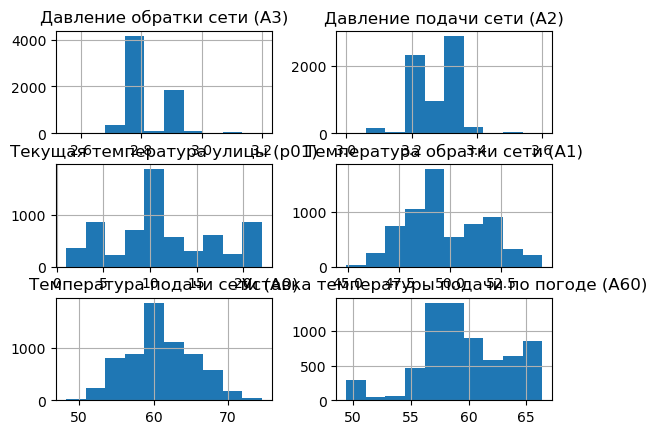

In [57]:
train4[[c for c in train4.columns if not c.startswith('miss_')]].hist()

array([[<Axes: title={'center': 'Давление обратки сети (A3)'}>,
        <Axes: title={'center': 'Давление подачи сети (A2)'}>],
       [<Axes: title={'center': 'Текущая температура улицы (p01)'}>,
        <Axes: title={'center': 'Температура обратки сети (A1)'}>],
       [<Axes: title={'center': 'Температура подачи сети (A0)'}>,
        <Axes: title={'center': 'Уставка температуры подачи по погоде (A60)'}>]],
      dtype=object)

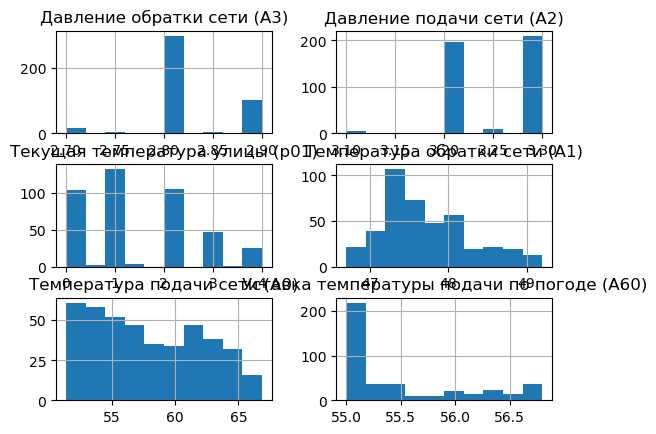

In [58]:
test41[[c for c in test41.columns if not c.startswith('miss_')]].hist()

In [59]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test41_post = add_target_column(
    test41,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test42_post = add_target_column(
    test42,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test43_post = add_target_column(
    test43,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [60]:
print(test41_post['target'].sum())
print(test42_post['target'].sum())
print(test43_post['target'].sum())

30
87
82


In [61]:
train4.to_csv('data_post/unsupervised/4/train.csv')
val4.to_csv('data_post/unsupervised/4/val.csv')
test41_post.to_csv('data_post/unsupervised/4/test1.csv')
test42_post.to_csv('data_post/unsupervised/4/test2.csv')
test43_post.to_csv('data_post/unsupervised/4/test3.csv')

#### supervised

In [26]:
# загрузка
train4 = pd.read_excel('data/supervised/4/train.xlsx', index_col=0)
test4 = pd.read_excel('data/supervised/4/test.xlsx', index_col=0)

In [27]:
train4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7966 entries, 2026-02-06 09:48:28 to 2026-02-10 17:59:31
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Давление обратки сети (A3)                  7966 non-null   float64
 1   Давление подачи сети (A2)                   7966 non-null   float64
 2   Текущая температура улицы (p01)             7966 non-null   int64  
 3   Температура обратки сети (A1)               7966 non-null   float64
 4   Температура подачи сети (A0)                7966 non-null   float64
 5   Уставка температуры подачи по погоде (A60)  7966 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 435.6 KB


In [28]:
test4.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3015 entries, 2026-02-10 18:00:18 to 2026-02-12 09:47:55
Data columns (total 6 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Давление обратки сети (A3)                  3015 non-null   float64
 1   Давление подачи сети (A2)                   3015 non-null   float64
 2   Текущая температура улицы (p01)             3015 non-null   int64  
 3   Температура обратки сети (A1)               3015 non-null   float64
 4   Температура подачи сети (A0)                3015 non-null   float64
 5   Уставка температуры подачи по погоде (A60)  3015 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 164.9 KB


In [29]:
min_len, median_len = event_lengths(list4)['min'], event_lengths(list4)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 14 64 32


In [30]:
freq_data = '1min'
train4, val4, train_col = preprocess(train4, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test4 = preprocess(test4, freq=freq_data, max_interp_gap=gap_fill)

In [31]:
for i in range(0, train4.shape[1], 30):
    print((train4.columns[i:i+30] ==test4.columns[i:i+30]).sum() == len(train4.columns[i:i+30] ==test4.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [32]:
print(train4.shape, val4.shape, test4.shape)

(5001, 13) (1251, 13) (2388, 13)


In [33]:
print(train4['miss_all'].sum())
print(val4['miss_all'].sum())
print(test4['miss_all'].sum())

68
30
60


In [34]:
print(train4.isna().sum().sum())
print(val4.isna().sum().sum())
print(test4.isna().sum().sum())

0
0
0


In [35]:
train4[[c for c in train4.columns if not c.startswith('miss_')]].describe()

,Давление обратки сети (A3),Давление подачи сети (A2),Текущая температура улицы (p01),Температура обратки сети (A1),Температура подачи сети (A0),Уставка температуры подачи по погоде (A60)
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,2.832059,3.259058,10.175365,49.342317,60.408938,58.705059
std,0.068340,0.068194,6.585678,2.096283,4.964376,4.176693
min,2.550000,3.000000,0.000000,44.900000,48.200000,49.400000
25%,2.800000,3.200000,4.000000,47.700000,56.200000,56.200000
50%,2.800000,3.300000,9.500000,48.800000,60.350000,57.600000
75%,2.900000,3.300000,15.000000,50.600000,64.200000,60.900000
max,3.200000,3.600000,22.000000,54.500000,74.600000,66.400000


In [36]:
test4[[c for c in test4.columns if not c.startswith('miss_')]].describe()

,Давление обратки сети (A3),Давление подачи сети (A2),Текущая температура улицы (p01),Температура обратки сети (A1),Температура подачи сети (A0),Уставка температуры подачи по погоде (A60)
count,2388.000000,2388.000000,2388.000000,2388.000000,2388.000000,2388.000000
mean,2.819577,3.222320,5.403057,49.195771,59.856376,58.084851
std,0.107398,0.116991,4.191972,1.670166,4.676372,2.396115
min,0.000000,0.000000,0.000000,44.450000,48.300000,47.800000
25%,2.800000,3.200000,1.000000,48.600000,56.450000,57.350000
50%,2.800000,3.200000,5.000000,49.600000,59.600000,58.300000
75%,2.900000,3.300000,9.000000,50.100000,63.562500,59.500000
max,3.000000,3.400000,14.000000,51.900000,71.200000,62.200000


array([[<Axes: title={'center': 'Давление обратки сети (A3)'}>,
        <Axes: title={'center': 'Давление подачи сети (A2)'}>],
       [<Axes: title={'center': 'Текущая температура улицы (p01)'}>,
        <Axes: title={'center': 'Температура обратки сети (A1)'}>],
       [<Axes: title={'center': 'Температура подачи сети (A0)'}>,
        <Axes: title={'center': 'Уставка температуры подачи по погоде (A60)'}>]],
      dtype=object)

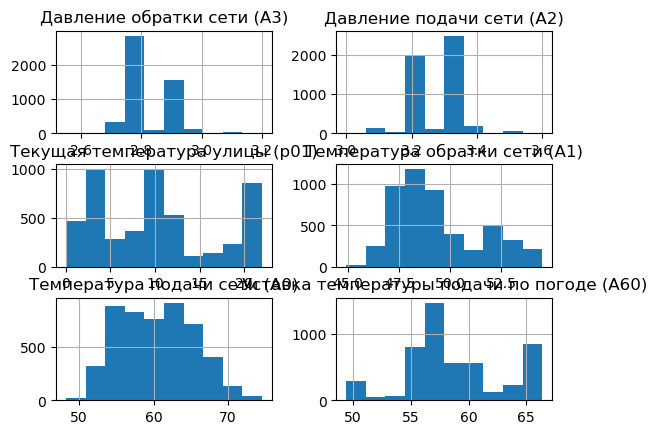

In [37]:
train4[[c for c in train4.columns if not c.startswith('miss_')]].hist()

array([[<Axes: title={'center': 'Давление обратки сети (A3)'}>,
        <Axes: title={'center': 'Давление подачи сети (A2)'}>],
       [<Axes: title={'center': 'Текущая температура улицы (p01)'}>,
        <Axes: title={'center': 'Температура обратки сети (A1)'}>],
       [<Axes: title={'center': 'Температура подачи сети (A0)'}>,
        <Axes: title={'center': 'Уставка температуры подачи по погоде (A60)'}>]],
      dtype=object)

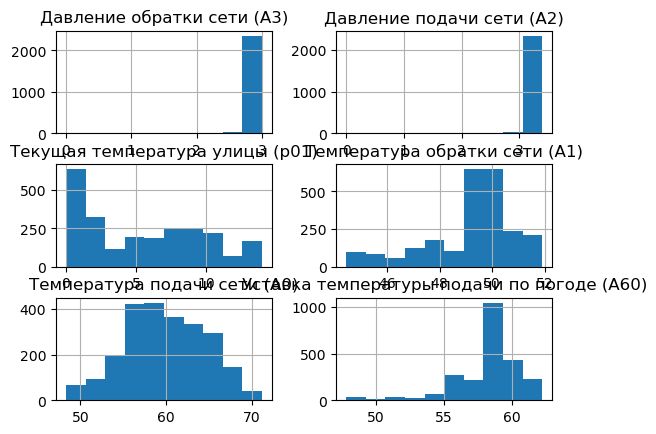

In [38]:
test4[[c for c in test4.columns if not c.startswith('miss_')]].hist()

In [39]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
train4_post = add_target_column(
    train4,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
val4_post = add_target_column(
    val4,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)
test4_post = add_target_column(
    test4,
    anomaly_intervals=list4,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [40]:
print(train4_post['target'].sum())
print(val4_post['target'].sum())
print(test4_post['target'].sum())

30
87
82


In [41]:
train4_post.to_csv('data_post/supervised/4/train.csv')
val4_post.to_csv('data_post/supervised/4/val.csv')
test4_post.to_csv('data_post/supervised/4/test.csv')

#### оптимизация

In [ ]:
#import optuna

# ВАЖНО: эти функции у тебя уже есть:
# - pick_threshold_by_false_alarms_day(...)
# - false_alarms_per_day_from_scores(...)
# - binary_to_events(...) (используется внутри)
#
# Также у тебя уже есть:
# train_data, val_data (TimeSeries)
# model = AutoEncoder(config) из Merlion

#def objective(trial):
    # -----------------------
    # 1) Sample hyperparams
    # -----------------------
#    hidden_size = trial.suggest_int('hidden_size', 8, 64)
#    num_epochs  = trial.suggest_int('num_epochs', 10, 120)
#    batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
#    lr          = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)

    # пример для layer_sizes (подстрой под то, что принимает AutoEncoderConfig)
#    l1 = trial.suggest_int('l1', 16, 128)
#    l2 = trial.suggest_int('l2', 16, 256)
#    l3 = trial.suggest_int('l3', 16, 256)
#    layer_sizes = (l1, l2, l3)

    # пост-агрегация событий (фиксируем для честного сравнения)
#    gap_minutes = 2
#    min_event_len_minutes = 2

    # эксплуатационный лимит (его не оптимизируем, фиксируем)
#    max_fa_day = 1.0  # например: <= 1 ложного события/сутки на норме

    # вес за 'качество нормы'
    # чем больше lambda_norm, тем сильнее Optuna будет 'стягивать' score на норме вниз
#    lambda_norm = 0.1

    # -----------------------
    # 2) Train model
    # -----------------------
#    config = AutoEncoderConfig(
#        hidden_size=hidden_size,
#        layer_sizes=layer_sizes,
#        sequence_len=5,
#        num_epochs=num_epochs,
#        batch_size=batch_size,
#        learning_rate=lr,
#        transform=None,
#        threshold=None  # порог выбираем отдельно
#    )

#    model = AutoEncoder(config)
#    model.train(train_data)

    # -----------------------
    # 3) Scores on normal-only val
    # -----------------------
#    val_scores = model.get_anomaly_score(val_data).to_pd().squeeze()
#    val_scores = val_scores.astype(float).dropna().sort_index()

    # защита от странных trial-ов
#    if val_scores.empty or not np.isfinite(val_scores.values).all():
#        return 1e6

    # -----------------------
    # 4) Threshold protocol: pick thr s.t. FA/day <= max_fa_day
    # -----------------------
#    thr, fa_day = pick_threshold_by_false_alarms_day(
#        val_scores,
#        max_false_alarms_day=max_fa_day,
#        gap_minutes=gap_minutes,
#        min_event_len_minutes=min_event_len_minutes
#    )

    # если модель слишком шумная и не удаётся подобрать порог под ограничение
#    if thr is None or fa_day is None or np.isnan(fa_day):
#        return 1e6

    # -----------------------
    # 5) 'Normal fit' proxy
    # -----------------------
    # На норме чем меньше score (ошибка реконструкции/аномальности), тем лучше.
    # Используем robust статистику, чтобы не ловить единичные выбросы.
#    norm_proxy = float(np.median(val_scores.values))  # можно mean, но median стабильнее

    # -----------------------
    # 6) Combined objective
    # -----------------------
    # Минимизируем: (FA/day) + lambda * median(score)
    # FA/day уже 'в пределах' лимита, но Optuna будет искать ещё меньше FA/day и лучше fit нормы
#    loss = float(fa_day) + float(lambda_norm) * norm_proxy

    # логируем полезные штуки в trial
#    trial.set_user_attr('thr', float(thr))
#    trial.set_user_attr('fa_day', float(fa_day))
#    trial.set_user_attr('val_score_median', float(norm_proxy))

#    return loss


#study = optuna.create_study(direction='minimize')
#study.optimize(objective, n_trials=30)

#print('Best loss:', study.best_value)
#print('Best params:', study.best_params)
#print('Best trial attrs:', study.best_trial.user_attrs)

### 6

#### supervised

In [10]:
# загрузка
train6 = pd.read_excel('data/supervised/6/train.xlsx', index_col=0)
test6 = pd.read_excel('data/supervised/6/test.xlsx', index_col=0)

In [11]:
train6.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 66929 entries, 2025-12-10 00:00:30 to 2026-01-21 23:59:34
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Измеренная величина 1 (PV1)        60849 non-null  float64
 1   Выходной сигнал канала 1 (r.out1)  60849 non-null  float64
 2   Уставка регулятора 1 (SP1)         66929 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 2.0 MB


In [12]:
test6.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 51353 entries, 2026-01-22 00:00:28 to 2026-02-23 23:58:55
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Измеренная величина 1 (PV1)        46680 non-null  float64
 1   Выходной сигнал канала 1 (r.out1)  46680 non-null  float64
 2   Уставка регулятора 1 (SP1)         51353 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 1.6 MB


In [13]:
min_len, median_len = event_lengths(list6)['min'], event_lengths(list6)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

3 3 20 5


In [14]:
train6.describe()

,Измеренная величина 1 (PV1),Выходной сигнал канала 1 (r.out1),Уставка регулятора 1 (SP1)
count,60849.000000,60849.000000,66929.0
mean,5.078499,0.242075,5.0
std,0.891454,1.536940,0.0
min,2.300000,0.000000,5.0
25%,4.400000,0.000000,5.0
50%,4.900000,0.000000,5.0
75%,5.500000,0.000000,5.0
max,11.300000,10.000000,5.0


In [15]:
freq_data = '1min'
val6, train6, train_col = preprocess(train6, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True, val_size=0.2)
test6 = preprocess(test6, freq=freq_data, max_interp_gap=gap_fill)

In [48]:
print(train6.shape, val6.shape, test6.shape)

(49536, 7) (12384, 7) (47519, 7)


In [17]:
for i in range(0, train6.shape[1], 30):
    print((train6.columns[i:i+30] ==test6.columns[i:i+30]).sum() == len(train6.columns[i:i+30] ==test6.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [18]:
print(train6['miss_all'].sum())
print(val6['miss_all'].sum())
print(test6['miss_all'].sum())

883
188
839


In [19]:
train6.describe()

,Измеренная величина 1 (PV1),Выходной сигнал канала 1 (r.out1),Уставка регулятора 1 (SP1),miss_all,miss_Измеренная величина 1 (PV1),miss_Выходной сигнал канала 1 (r.out1),miss_Уставка регулятора 1 (SP1)
count,49536.000000,49536.000000,49536.000000,49536.000000,49536.000000,49536.000000,49536.000000
mean,4.967265,0.266271,4.984052,0.017825,0.017825,0.017825,0.016231
std,0.802884,1.609926,0.281935,0.132318,0.132318,0.132318,0.126363
min,3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.400000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,4.800000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,5.400000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
max,11.300000,10.000000,5.000000,1.000000,1.000000,1.000000,1.000000


In [20]:
test6.describe()

,Измеренная величина 1 (PV1),Выходной сигнал канала 1 (r.out1),Уставка регулятора 1 (SP1),miss_all,miss_Измеренная величина 1 (PV1),miss_Выходной сигнал канала 1 (r.out1),miss_Уставка регулятора 1 (SP1)
count,47519.000000,47519.000000,47519.000000,47519.000000,47519.000000,47519.000000,47519.000000
mean,5.028982,0.758644,4.991267,0.017656,0.017656,0.017656,0.016478
std,0.978927,2.647838,0.208786,0.131699,0.131699,0.131699,0.127305
min,-3.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.400000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,4.800000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,5.500000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
max,13.400000,10.000000,5.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#train3.hist()

In [ ]:
#test3.hist()

In [24]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
train6_post = add_target_column(
    train6,
    anomaly_intervals=list6,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

val6_post = add_target_column(
    val6,
    anomaly_intervals=list6,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

# Добавляем столбец target (1 – аномалия, 0 – норма)
test6_post = add_target_column(
    test6,
    anomaly_intervals=list6,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [22]:
print(train6_post['target'].sum())
print(val6_post['target'].sum())
print(test6_post['target'].sum())

24
12
134


In [25]:
train6_post.to_csv('data_post/supervised/6/train.csv')
val6_post.to_csv('data_post/supervised/6/val.csv')
test6_post.to_csv('data_post/supervised/6/test.csv')

#### unsupervised

In [202]:
# загрузка
train6 = pd.read_excel('data/unsupervised/6/6_train.xlsx', index_col=0)
test61 = pd.read_excel('data/unsupervised/6/6_test1.xlsx', index_col=0)
test62 = pd.read_excel('data/unsupervised/6/6_test2.xlsx', index_col=0)

In [185]:
train6.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 32759 entries, 2026-01-01 00:00:54 to 2026-01-21 23:59:34
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Измеренная величина 1 (PV1)        29782 non-null  float64
 1   Выходной сигнал канала 1 (r.out1)  29782 non-null  float64
 2   Уставка регулятора 1 (SP1)         32759 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 1023.7 KB


In [83]:
test61.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34170 entries, 2025-12-10 00:00:30 to 2025-12-31 23:59:54
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Измеренная величина 1 (PV1)        31067 non-null  float64
 1   Выходной сигнал канала 1 (r.out1)  31067 non-null  float64
 2   Уставка регулятора 1 (SP1)         34170 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 1.0 MB


In [203]:
min_len, median_len = event_lengths(list6)['min'], event_lengths(list6)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

3 3 20 5


In [204]:
freq_data = '1min'
train6, val6, train_col = preprocess(train6, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test61 = preprocess(test61, freq=freq_data, max_interp_gap=gap_fill)
test62 = preprocess(test62, freq=freq_data, max_interp_gap=gap_fill)

Выбросы не найдены
Выбросы не найдены
Выбросы не найдены


In [205]:
print(train6.shape, val6.shape, test61.shape, test62.shape)

(24192, 7) (6048, 7) (31680, 7) (47519, 7)


In [206]:
for i in range(0, train6.shape[1], 30):
    print((train6.columns[i:i+30] ==test61.columns[i:i+30]).sum() == len(train6.columns[i:i+30] ==test61.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

for i in range(0, train6.shape[1], 30):
    print((train6.columns[i:i+30] ==test62.columns[i:i+30]).sum() == len(train6.columns[i:i+30] ==test62.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True
True


In [87]:
print(train6['miss_all'].sum())
print(val6['miss_all'].sum())
print(test61['miss_all'].sum())
print(test62['miss_all'].sum())

363
95
613
839


In [193]:
train6.describe()

,Измеренная величина 1 (PV1),Выходной сигнал канала 1 (r.out1),Уставка регулятора 1 (SP1),miss_all,miss_Измеренная величина 1 (PV1),miss_Выходной сигнал канала 1 (r.out1),miss_Уставка регулятора 1 (SP1)
count,24192.000000,24192.000000,24192.000000,24192.000000,24192.000000,24192.000000,24192.000000
mean,4.922970,0.322834,4.996486,0.015005,0.015005,0.015005,0.013434
std,0.717238,1.767554,0.132500,0.121575,0.121575,0.121575,0.115127
min,3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.300000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,4.800000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,5.400000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
max,7.500000,10.000000,5.000000,1.000000,1.000000,1.000000,1.000000


In [194]:
test61.describe()

,Измеренная величина 1 (PV1),Выходной сигнал канала 1 (r.out1),Уставка регулятора 1 (SP1),miss_all,miss_Измеренная величина 1 (PV1),miss_Выходной сигнал канала 1 (r.out1),miss_Уставка регулятора 1 (SP1)
count,31680.000000,31680.000000,31680.000000,31680.000000,31680.000000,31680.000000,31680.000000
mean,5.227236,0.138889,4.976641,0.019350,0.019350,0.019350,0.018056
std,1.011801,1.170317,0.340956,0.137753,0.137753,0.137753,0.133154
min,2.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.500000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,5.100000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
75%,5.600000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
max,11.300000,10.000000,5.000000,1.000000,1.000000,1.000000,1.000000


In [195]:
#train3.hist()

In [196]:
#test3.hist()

In [208]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test61_post = add_target_column(
    test61,
    anomaly_intervals=list6,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

# Добавляем столбец target (1 – аномалия, 0 – норма)
test62_post = add_target_column(
    test62,
    anomaly_intervals=list6,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [209]:
test61_post['target'].sum() + test62_post['target'].sum()

170

In [210]:
train6.to_csv('data_post/unsupervised/6/train.csv')
val6.to_csv('data_post/unsupervised/6/val.csv')
test61_post.to_csv('data_post/unsupervised/6/test1.csv')
test62_post.to_csv('data_post/unsupervised/6/test2.csv')

#### оптимизация

In [ ]:
#import optuna

# ВАЖНО: эти функции у тебя уже есть:
# - pick_threshold_by_false_alarms_day(...)
# - false_alarms_per_day_from_scores(...)
# - binary_to_events(...) (используется внутри)
#
# Также у тебя уже есть:
# train_data, val_data (TimeSeries)
# model = AutoEncoder(config) из Merlion

#def objective(trial):
    # -----------------------
    # 1) Sample hyperparams
    # -----------------------
#    hidden_size = trial.suggest_int('hidden_size', 8, 64)
#    num_epochs  = trial.suggest_int('num_epochs', 10, 120)
#    batch_size  = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
#    lr          = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)

    # пример для layer_sizes (подстрой под то, что принимает AutoEncoderConfig)
#    l1 = trial.suggest_int('l1', 16, 128)
#    l2 = trial.suggest_int('l2', 16, 256)
#    l3 = trial.suggest_int('l3', 16, 256)
#    layer_sizes = (l1, l2, l3)

    # пост-агрегация событий (фиксируем для честного сравнения)
#    gap_minutes = 2
#    min_event_len_minutes = 2

    # эксплуатационный лимит (его не оптимизируем, фиксируем)
#    max_fa_day = 1.0  # например: <= 1 ложного события/сутки на норме

    # вес за 'качество нормы'
    # чем больше lambda_norm, тем сильнее Optuna будет 'стягивать' score на норме вниз
#    lambda_norm = 0.1

    # -----------------------
    # 2) Train model
    # -----------------------
#    config = AutoEncoderConfig(
#        hidden_size=hidden_size,
#        layer_sizes=layer_sizes,
#        sequence_len=5,
#        num_epochs=num_epochs,
#        batch_size=batch_size,
#        learning_rate=lr,
#        transform=None,
#        threshold=None  # порог выбираем отдельно
#    )

#    model = AutoEncoder(config)
#    model.train(train_data)

    # -----------------------
    # 3) Scores on normal-only val
    # -----------------------
#    val_scores = model.get_anomaly_score(val_data).to_pd().squeeze()
#    val_scores = val_scores.astype(float).dropna().sort_index()

    # защита от странных trial-ов
#    if val_scores.empty or not np.isfinite(val_scores.values).all():
#        return 1e6

    # -----------------------
    # 4) Threshold protocol: pick thr s.t. FA/day <= max_fa_day
    # -----------------------
#    thr, fa_day = pick_threshold_by_false_alarms_day(
#        val_scores,
#        max_false_alarms_day=max_fa_day,
#        gap_minutes=gap_minutes,
#        min_event_len_minutes=min_event_len_minutes
#    )

    # если модель слишком шумная и не удаётся подобрать порог под ограничение
#    if thr is None or fa_day is None or np.isnan(fa_day):
#        return 1e6

    # -----------------------
    # 5) 'Normal fit' proxy
    # -----------------------
    # На норме чем меньше score (ошибка реконструкции/аномальности), тем лучше.
    # Используем robust статистику, чтобы не ловить единичные выбросы.
#    norm_proxy = float(np.median(val_scores.values))  # можно mean, но median стабильнее

    # -----------------------
    # 6) Combined objective
    # -----------------------
    # Минимизируем: (FA/day) + lambda * median(score)
    # FA/day уже 'в пределах' лимита, но Optuna будет искать ещё меньше FA/day и лучше fit нормы
#    loss = float(fa_day) + float(lambda_norm) * norm_proxy

    # логируем полезные штуки в trial
#    trial.set_user_attr('thr', float(thr))
#    trial.set_user_attr('fa_day', float(fa_day))
#    trial.set_user_attr('val_score_median', float(norm_proxy))

#    return loss


#study = optuna.create_study(direction='minimize')
#study.optimize(objective, n_trials=30)

#print('Best loss:', study.best_value)
#print('Best params:', study.best_params)
#print('Best trial attrs:', study.best_trial.user_attrs)

### 7

#### исследование

In [626]:
# загрузка
train7 = pd.read_excel('data/7/7_train.xlsx', index_col=0)
test7 = pd.read_excel('data/7/7_test.xlsx', index_col=0)

In [627]:
train7.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7097 entries, 2026-02-04 00:01:15 to 2026-02-28 23:56:35
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Test_D436_fl (Test_D436_fl)              7097 non-null   int64  
 1   Test_D438_fl (Test_D438_fl)              7097 non-null   int64  
 2   Test_D440_fl (Test_D440_fl)              7097 non-null   int64  
 3   Test_D442_fl (Test_D442_fl)              7097 non-null   float64
 4   Коррекция от превышения t (Korrect-OH)   7097 non-null   object 
 5   Коррекция от снижения t (Korrect-OC)     7097 non-null   object 
 6   Насос N1 (Pump1-R)                       7097 non-null   object 
 7   Насос N2 (Pump2-R)                       7097 non-null   object 
 8   Вентиль - положение (Valve)              7097 non-null   float64
 9   Давление 1 - Сеть Подача (P1)            7097 non-null   float64
 10  Давление 2 -

In [628]:
test7.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1136 entries, 2026-03-01 00:01:40 to 2026-03-04 23:59:17
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Test_D436_fl (Test_D436_fl)              1136 non-null   int64  
 1   Test_D438_fl (Test_D438_fl)              1136 non-null   int64  
 2   Test_D440_fl (Test_D440_fl)              1136 non-null   int64  
 3   Test_D442_fl (Test_D442_fl)              1136 non-null   float64
 4   Коррекция от превышения t (Korrect-OH)   1136 non-null   object 
 5   Коррекция от снижения t (Korrect-OC)     1136 non-null   object 
 6   Насос N1 (Pump1-R)                       1136 non-null   object 
 7   Насос N2 (Pump2-R)                       1136 non-null   object 
 8   Вентиль - положение (Valve)              1136 non-null   float64
 9   Давление 1 - Сеть Подача (P1)            1136 non-null   float64
 10  Давление 2 -

In [629]:
for i in test7.columns:
    test7.loc[test7[i] == 'Ошибка  255', i] = np.nan
    #print(i, test7[i].unique())

In [630]:
# список блоков аномалий
list7 = [['2026-03-03 09:15', '2026-03-03 09:30'], ['2026-03-03 13:10', '2026-03-03 13:20'], ['2026-03-04 13:00', '2026-03-04 13:20']]

min_len, median_len = event_lengths(list7)['min'], event_lengths(list7)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

10 5 20 6


In [631]:
freq_data = '5min'
train7, val7, train_col = preprocess(train7, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test7 = preprocess(test7, freq=freq_data, max_interp_gap=gap_fill)

In [632]:
print(train7.shape, test7.shape)

(5760, 59) (1152, 59)


In [633]:
for i in range(0, train7.shape[1], 30):
    print((train7.columns[i:i+30] ==test7.columns[i:i+30]).sum() == len(train7.columns[i:i+30] ==test7.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True
True


In [634]:
train7.describe()

,Test_D436_fl (Test_D436_fl),Test_D438_fl (Test_D438_fl),Test_D440_fl (Test_D440_fl),Test_D442_fl (Test_D442_fl),Вентиль - положение (Valve),Давление 1 - Сеть Подача (P1),Давление 2 - Сеть Обратка (P2),Давление 3 - Отопление (P3),Подпитка (Accum_Units),Расход 1 - Подпитка (F1),...,miss_Насос N1 (Pump1-R),miss_Насос N2 (Pump2-R),Коррекция от превышения t (Korrect-OH)_Не работает,Коррекция от превышения t (Korrect-OH)_Работает,Коррекция от снижения t (Korrect-OC)_Не работает,Коррекция от снижения t (Korrect-OC)_Работает,Насос N1 (Pump1-R)_Включен,Насос N1 (Pump1-R)_Отключен,Насос N2 (Pump2-R)_Включен,Насос N2 (Pump2-R)_Отключен
count,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.0,5760.0,...,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000
mean,109.982639,3.086458,542.083333,0.054208,25.518802,6.761693,5.512882,3.306858,0.0,0.0,...,0.014236,0.014236,0.866493,0.133507,0.453299,0.546701,0.432292,0.567708,0.567708,0.432292
std,165.636626,2.657406,830.576179,0.083058,15.665944,0.147559,0.056037,0.600163,0.0,0.0,...,0.118473,0.118473,0.340151,0.340151,0.497857,0.497857,0.495437,0.495437,0.495437,0.495437
min,-200.000000,0.000000,-1800.000000,-0.180000,1.000000,6.300000,5.000000,2.300000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,11.800000,6.700000,5.500000,2.800000,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,250.000000,3.000000,500.000000,0.050000,21.400000,6.750000,5.500000,3.200000,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
75%,250.000000,5.000000,1250.000000,0.125000,39.800000,6.900000,5.500000,3.800000,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,250.000000,9.000000,1750.000000,0.175000,53.400000,7.500000,6.000000,4.400000,0.0,0.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [635]:
test7.describe()

,Test_D436_fl (Test_D436_fl),Test_D438_fl (Test_D438_fl),Test_D440_fl (Test_D440_fl),Test_D442_fl (Test_D442_fl),Вентиль - положение (Valve),Давление 1 - Сеть Подача (P1),Давление 2 - Сеть Обратка (P2),Давление 3 - Отопление (P3),Подпитка (Accum_Units),Расход 1 - Подпитка (F1),...,miss_Насос N1 (Pump1-R),miss_Насос N2 (Pump2-R),Коррекция от превышения t (Korrect-OH)_Не работает,Коррекция от превышения t (Korrect-OH)_Работает,Коррекция от снижения t (Korrect-OC)_Не работает,Коррекция от снижения t (Korrect-OC)_Работает,Насос N1 (Pump1-R)_Включен,Насос N1 (Pump1-R)_Отключен,Насос N2 (Pump2-R)_Включен,Насос N2 (Pump2-R)_Отключен
count,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.0,1152.0,...,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000,1152.000000
mean,137.977431,3.900174,783.637153,0.078364,28.879123,6.747005,5.507812,3.289366,0.0,0.0,...,0.014757,0.014757,0.888021,0.111979,0.358507,0.641493,0.414062,0.585938,0.585938,0.414062
std,159.865244,2.887933,904.726973,0.090473,17.186130,0.155558,0.056465,0.489771,0.0,0.0,...,0.120631,0.120631,0.315478,0.315478,0.479770,0.479770,0.492773,0.492773,0.492773,0.492773
min,-200.000000,0.000000,-1000.000000,-0.100000,3.500000,5.800000,5.300000,2.300000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.750000,0.000000,0.000000,12.400000,6.600000,5.500000,2.900000,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,250.000000,4.000000,1000.000000,0.100000,24.400000,6.800000,5.500000,3.300000,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
75%,250.000000,7.000000,1750.000000,0.175000,49.800000,6.900000,5.500000,3.600000,0.0,0.0,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,250.000000,10.000000,2500.000000,0.250000,50.000000,7.200000,5.600000,4.400000,0.0,0.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [636]:
#train7.hist()

In [637]:
#test7.hist()

In [638]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test7_post = add_target_column(
    test7,
    anomaly_intervals=list7,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [639]:
test7_post['target'].sum()

12

In [ ]:
#train7.to_csv('data_post/7/train7.csv')
#val7.to_csv('data_post/7/val7.csv')
#test7_post.to_csv('data_post/7/test7.csv')

### 8

#### исследование

In [9]:
# загрузка
train8 = pd.read_excel('data/8/train8.xlsx', index_col=0)
test8 = pd.read_excel('data/8/test8.xlsx', index_col=0)

In [10]:
train8.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 49969 entries, 2026-02-26 00:21:41 to 2026-03-17 12:59:55
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Состояние датчика потока воздуха №1 (P571_14)       16288 non-null  object 
 1   Состояние датчика потока воздуха №2 (P572_15)       16288 non-null  object 
 2   Показания датчика аварийного озона (P528)           16288 non-null  float64
 3   Показания технологического датчика озона №1 (P512)  16288 non-null  float64
 4   Показания технологического датчика озона №2 (P520)  16288 non-null  float64
 5   Состояние компрессора 1 (P564)                      16288 non-null  object 
 6   Давление (P532)                                     16288 non-null  float64
 7   Минимальное давление (P533)                         49969 non-null  int64  
 8   Состояние генератора №1 (P565)           

In [11]:
test8.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12885 entries, 2026-02-21 00:00:09 to 2026-02-25 23:50:07
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Состояние датчика потока воздуха №1 (P571_14)       4203 non-null   object 
 1   Состояние датчика потока воздуха №2 (P572_15)       4203 non-null   object 
 2   Показания датчика аварийного озона (P528)           4203 non-null   float64
 3   Показания технологического датчика озона №1 (P512)  4203 non-null   float64
 4   Показания технологического датчика озона №2 (P520)  4203 non-null   float64
 5   Состояние компрессора 1 (P564)                      4203 non-null   object 
 6   Давление (P532)                                     4203 non-null   float64
 7   Минимальное давление (P533)                         12885 non-null  int64  
 8   Состояние генератора №1 (P565)           

In [12]:
for i in train8.columns:
    train8.loc[train8[i] == 'Ошибка  255', i] = np.nan
    #print(i, test7[i].unique())

In [13]:
for i in test8.columns:
    test8.loc[test8[i] == 'Ошибка  255', i] = np.nan
    #print(i, test7[i].unique())

In [14]:
for i in train8.select_dtypes(exclude=['number']).columns:
    print(train8[i].unique())

for i in test8.select_dtypes(exclude=['number']).columns:
    print(test8[i].unique())

['Есть сигнал' nan 'Нет сигнала']
['Нет сигнала' nan 'Есть сигнал']
['Работа' nan 'Пауза']
['Работа' nan 'Отдых']
['Пауза' nan 'Работа']
['Отдых' nan 'Работа' 'Пауза']
[nan 'Есть сигнал' 'Нет сигнала']
[nan 'Нет сигнала' 'Есть сигнал']
[nan 'Пауза' 'Работа' 'Авария']
[nan 'Отдых' 'Работа']
[nan 'Работа' 'Пауза']
[nan 'Работа' 'Отдых' 'Пауза']


In [15]:
# список блоков аномалий
list8 = [['2026-02-23 09:44', '2026-02-23 13:19'], ['2026-02-24 13:26', '2026-02-24 13:42'], ['2026-02-24 13 17:36', '2026-02-24 19:36']]

min_len, median_len = event_lengths(list8)['min'], event_lengths(list8)['median']
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 8 96 48


In [16]:
freq_data = '1min'
train8, val8, train_col = preprocess(train8, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test8 = preprocess(test8, freq=freq_data, max_interp_gap=gap_fill, fit_dummy_columns=train_col)

In [17]:
print(train8.shape, test8.shape)

(22495, 34) (7191, 34)


In [18]:
for i in range(0, train8.shape[1], 30):
    print((train8.columns[i:i+30] ==test8.columns[i:i+30]).sum() == len(train8.columns[i:i+30] ==test8.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True
True


In [19]:
train8.iloc[:, :9].describe()

,Показания датчика аварийного озона (P528),Показания технологического датчика озона №1 (P512),Показания технологического датчика озона №2 (P520),Давление (P532),Минимальное давление (P533),Давление (P535),Минимальное давление (P536),miss_all,miss_Показания датчика аварийного озона (P528)
count,22495.000000,22495.0,22495.000000,22495.000000,22495.0,22495.000000,22495.0,22495.000000,22495.000000
mean,0.042453,0.0,1.456323,173.368726,20.0,8.532229,60.0,0.421338,0.421338
std,0.109239,0.0,1.322686,59.414061,0.0,24.902632,0.0,0.493785,0.493785
min,0.000000,0.0,0.001000,0.000000,20.0,0.000000,60.0,0.000000,0.000000
25%,0.001000,0.0,0.514000,161.000000,20.0,0.000000,60.0,0.000000,0.000000
50%,0.004500,0.0,0.957000,187.500000,20.0,0.000000,60.0,0.000000,0.000000
75%,0.052000,0.0,2.244750,210.000000,20.0,0.000000,60.0,1.000000,1.000000
max,2.462000,0.0,9.990000,242.000000,20.0,134.000000,60.0,1.000000,1.000000


In [20]:
test8.iloc[:, :7].describe()

,Показания датчика аварийного озона (P528),Показания технологического датчика озона №1 (P512),Показания технологического датчика озона №2 (P520),Давление (P532),Минимальное давление (P533),Давление (P535),Минимальное давление (P536)
count,7191.000000,7191.0,7191.000000,7191.000000,7191.000000,7191.000000,7191.000000
mean,0.035799,0.0,1.559643,86.133917,65.594841,41.014602,81.362815
std,0.091644,0.0,1.579709,76.488658,37.255203,59.152656,19.953508
min,0.000000,0.0,0.002000,0.000000,20.000000,0.000000,60.000000
25%,0.000000,0.0,0.031000,0.000000,20.000000,0.000000,60.000000
50%,0.001000,0.0,1.297000,73.000000,100.000000,0.000000,100.000000
75%,0.040000,0.0,2.647000,155.000000,100.000000,108.000000,100.000000
max,1.712000,0.0,9.989000,241.000000,100.000000,167.000000,100.000000


In [21]:
#train7.hist()

In [22]:
#test7.hist()

In [23]:
# Добавляем столбец target (1 – аномалия, 0 – норма)
test8_post = add_target_column(
    test8,
    anomaly_intervals=list8,
    target_col_name='target',
    inclusive='both'  # включаем обе границы интервала
)

In [24]:
test8_post['target'].sum()

354

In [25]:
#train8.to_csv('data_post/8/train8.csv')
#val8.to_csv('data_post/8/val8.csv')
#test8_post.to_csv('data_post/8/test8.csv')

### 9

In [57]:
# загрузка
df = pd.read_excel('data/supervised/9/9.xlsx', index_col=0)
#train9 = pd.read_excel('data/supervised/9/train.xlsx', index_col=0)
#test9 = pd.read_excel('data/supervised/9/test.xlsx', index_col=0)

In [58]:
split_idx = int(len(df) * 0.8)
train9 = df.iloc[:split_idx]
test9 = df.iloc[split_idx:]

In [59]:
train9.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28300 entries, 2026-02-18 09:20:51 to 2026-03-06 05:03:03
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Значение тока (in.i1)  28300 non-null  float64
 1   target                 28300 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 663.3 KB


In [60]:
test9.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7075 entries, 2026-03-06 05:03:04 to 2026-03-10 09:19:12
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Значение тока (in.i1)  7075 non-null   float64
 1   target                 7075 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 165.8 KB


In [61]:
min_len, median_len = get_anomaly_lengths_time(train9)
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

15 50 300 120


In [62]:
freq_data = '1min'
train9, val9, train_col = preprocess(train9, freq=freq_data, max_interp_gap=gap_fill, add_val=True, return_dummy_columns=True)
test9 = preprocess(test9, freq=freq_data, max_interp_gap=gap_fill)

In [63]:
print(train9.shape, val9.shape, test9.shape)

(18227, 4) (4557, 4) (6017, 4)


In [64]:
for i in range(0, train9.shape[1], 30):
    print((train9.columns[i:i+30] ==test9.columns[i:i+30]).sum() == len(train9.columns[i:i+30] ==test9.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [65]:
print(train9['miss_all'].sum())
print(val9['miss_all'].sum())
print(test9['miss_all'].sum())

9087
2144
3188


In [66]:
train9['target'].unique()

array([1, 0])

In [68]:
train9.describe()

,Значение тока (in.i1),miss_all,miss_Значение тока (in.i1),target
count,18227.000000,18227.000000,18227.000000,18227.000000
mean,0.399793,0.498546,0.498546,0.243211
std,0.317018,0.500012,0.500012,0.429033
min,0.090000,0.000000,0.000000,0.000000
25%,0.090000,0.000000,0.000000,0.000000
50%,0.430000,0.000000,0.000000,0.000000
75%,0.670000,1.000000,1.000000,0.000000
max,4.265000,1.000000,1.000000,1.000000


In [69]:
test9.describe()

,Значение тока (in.i1),miss_all,miss_Значение тока (in.i1),target
count,6017.000000,6017.000000,6017.000000,6017.000000
mean,0.349223,0.529832,0.529832,0.086256
std,0.300203,0.499151,0.499151,0.280764
min,0.090000,0.000000,0.000000,0.000000
25%,0.090000,0.000000,0.000000,0.000000
50%,0.092222,1.000000,1.000000,0.000000
75%,0.670000,1.000000,1.000000,0.000000
max,2.603333,1.000000,1.000000,1.000000


In [ ]:
#train3.hist()

In [ ]:
#test3.hist()

In [70]:
print(train9['target'].sum())
print(val9['target'].sum())
print(test9['target'].sum())

4433
2029
519


In [71]:
train9.to_csv('data_post/supervised/9/train.csv')
val9.to_csv('data_post/supervised/9/val.csv')
test9.to_csv('data_post/supervised/9/test.csv')

### 11

#### supervised

In [72]:
# загрузка
df = pd.read_excel('data/supervised/11/11.xlsx', index_col=0)
#train11 = pd.read_excel('data/supervised/11/train.xlsx', index_col=0)
#test11 = pd.read_excel('data/supervised/11/test.xlsx', index_col=0)

In [77]:
split_idx = int(len(df) * 0.8)
train11 = df.iloc[:split_idx]
test11 = df.iloc[split_idx:]

In [74]:
train11.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61459 entries, 2026-02-14 00:00:28 to 2026-03-29 06:36:34
Data columns (total 2 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Камера 4 Температура (UID1073741842)  61457 non-null  float64
 1   Камера 4 Влажность (UID1073741832)    61458 non-null  float64
dtypes: float64(2)
memory usage: 1.4 MB


In [75]:
test11.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 15365 entries, 2026-03-29 06:37:34 to 2026-04-08 23:59:11
Data columns (total 2 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Камера 4 Температура (UID1073741842)  15365 non-null  float64
 1   Камера 4 Влажность (UID1073741832)    15365 non-null  float64
dtypes: float64(2)
memory usage: 360.1 KB


In [78]:
freq_data = '1min'
train11, val11, train_col = preprocess(train11, freq=freq_data, add_val=True, return_dummy_columns=True)
test11 = preprocess(test11, freq=freq_data)

In [79]:
for i in range(0, train11.shape[1], 30):
    print((train11.columns[i:i+30] ==test11.columns[i:i+30]).sum() == len(train11.columns[i:i+30] ==test11.columns[i:i+30]))
    #print(train2.columns[i:i+30] ==test2.columns[i:i+30])

True


In [80]:
print(train11.shape, val11.shape, test11.shape)

(49853, 5) (12464, 5) (15443, 5)


In [82]:
print(train11['miss_all'].sum())
print(val11['miss_all'].sum())
print(test11['miss_all'].sum())

804
63
80


In [83]:
train11[[c for c in train11.columns if not c.startswith('miss_')]].describe()

,Камера 4 Температура (UID1073741842),Камера 4 Влажность (UID1073741832)
count,49853.000000,49853.000000
mean,-14.549871,72.923286
std,0.727668,6.924442
min,-16.000000,59.000000
25%,-15.000000,67.300000
50%,-14.700000,73.300000
75%,-14.300000,77.300000
max,-7.900000,97.000000


In [85]:
test11[[c for c in test11.columns if not c.startswith('miss_')]].describe()

,Камера 4 Температура (UID1073741842),Камера 4 Влажность (UID1073741832)
count,15443.000000,15443.000000
mean,-14.435217,76.020799
std,0.878596,6.810092
min,-15.600000,62.800000
25%,-14.900000,70.800000
50%,-14.600000,76.200000
75%,-14.300000,80.200000
max,-7.200000,96.900000


array([[<Axes: title={'center': 'Камера 4 Температура (UID1073741842)'}>,
        <Axes: title={'center': 'Камера 4 Влажность (UID1073741832)'}>]],
      dtype=object)

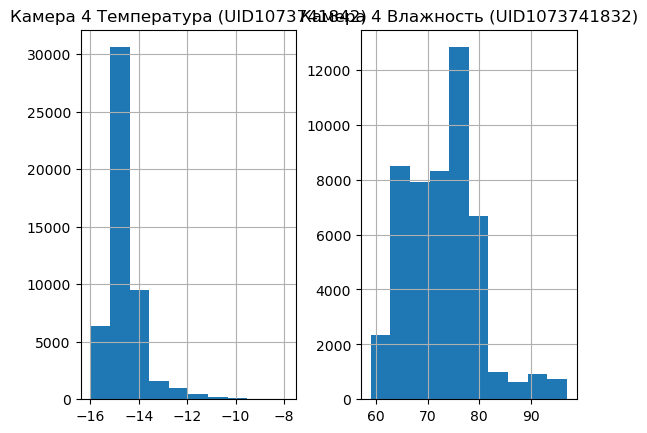

In [84]:
train11[[c for c in train11.columns if not c.startswith('miss_')]].hist()

array([[<Axes: title={'center': 'Камера 4 Температура (UID1073741842)'}>,
        <Axes: title={'center': 'Камера 4 Влажность (UID1073741832)'}>]],
      dtype=object)

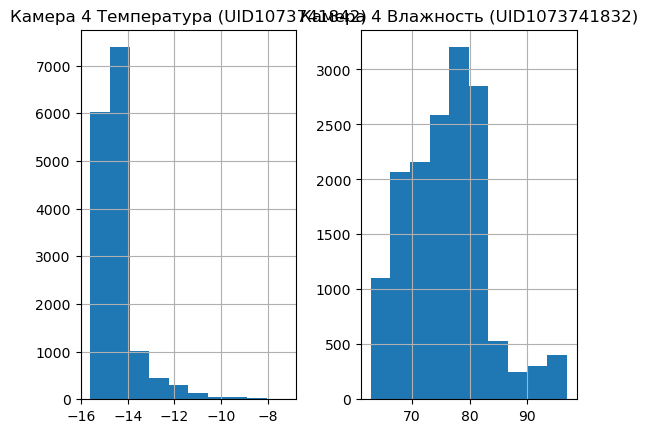

In [86]:
test11[[c for c in test11.columns if not c.startswith('miss_')]].hist()

In [87]:
train11_post = add_target_column1(train11)
val11_post = add_target_column1(val11)
test11_post = add_target_column1(test11)

In [89]:
min_len, median_len = get_anomaly_lengths_time(train11_post)
gap_fill, min_event, event_interval, window_size = event_params(min_len, median_len)
print(gap_fill, min_event, event_interval, window_size)

3 3 20 5


In [90]:
train11_post.to_csv('data_post/supervised/11/train.csv')
val11_post.to_csv('data_post/supervised/11/val.csv')
test11_post.to_csv('data_post/supervised/11/test.csv')

In [91]:
print(train11_post['target'].sum())
print(val11_post['target'].sum())
print(test11_post['target'].sum())

7393
5589
7075
